Portfolio Analysis; Portfolio analytics is done to reduce the risks in investing different assets (Stocks, bonds)

Here are the steps we are going to take to make measure and reduce the risks.

> * Raw Market Data
        ↓
> * Cleaning
        ↓
> * Returns
        ↓
> * Correlation
        ↓
> * Stationarity
        ↓
> * Granger Network
        ↓
> * Regime Detection
        ↓
> * Volatility Forecasting
        ↓
> * Monte Carlo Simulation
        ↓
> * Portfolio Optimization
        ↓
> * Risk Measurement

In [ ]:
!pip install networkx seaborn --upgrade

In [ ]:
pip install --upgrade pip

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import networkx as nx
import statsmodels.api as sm
from statsmodels.tsa.api import VAR

# Data Importation

Data Imported for this practice;

* Technology Companies
* Retail
* Cryptocurrencies
* Oil
* International Markets
* Volatility Index
* Macroeconomic Variables
  * Credit Risk conditions
  


In [ ]:
np.random.seed(42)

Macroeconomic Variables

These include indicators such as GDP, unemployment, inflation, policy interest rates, money supply, industrial production, exchange rates, and Treasury yields.

These describe the overall economy.

Think of them as the country's vital signs.

In [ ]:
from pandas.tseries import frequencies
import pandas as pd
import os
!pip install fredapi
from fredapi import Fred

fred = Fred(api_key='***REMOVED*** ')

seriesids=['GDP', 'UNRATE', 'PCEPILFE', 'FEDFUNDS', 'EFFR', 'INDPRO', 'M2SL']

data= {}
for sid in seriesids:
    try:
        data[sid] = fred.get_series(sid, observation_start='2020-01-01')
    except ValueError as e:
        print(f"Error fetching series '{sid}': {e}")
        data[sid] = None # Store None for failed series
Macroeconomic_indicators = pd.DataFrame(data)

In [ ]:
Macroeconomic_indicators

,GDP,UNRATE,PCEPILFE,FEDFUNDS,EFFR,INDPRO,M2SL
2020-01-01,21751.238,3.6,104.507,1.55,NaN,101.0338,15425.0
2020-01-02,NaN,NaN,NaN,NaN,1.55,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN,1.55,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN,1.55,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN,1.55,NaN,NaN
...,...,...,...,...,...,...,...
2026-07-31,NaN,NaN,NaN,NaN,3.63,NaN,NaN
2026-08-03,NaN,NaN,NaN,NaN,3.63,NaN,NaN
2026-08-04,NaN,NaN,NaN,NaN,3.63,NaN,NaN
2026-08-05,NaN,NaN,NaN,NaN,3.63,NaN,NaN


In [ ]:
Macroeconomic_indicators.isnull().sum()

,0
GDP,1718
UNRATE,1666
PCEPILFE,1666
FEDFUNDS,1665
EFFR,87
INDPRO,1666
M2SL,1666


In [ ]:
Macroeconomic_indicators.shape

(1744, 7)

In [ ]:
seriesids=['BAA', 'AAA', 'NFCI', 'STLFSI4']

data= {}
for sid in seriesids:
    data[sid] = fred.get_series(sid, observation_start='2020-01-01')
creditrisk_finconditions = pd.DataFrame(data)

In [ ]:
creditrisk_finconditions

,BAA,AAA,NFCI,STLFSI4
2020-01-01,3.77,2.94,NaN,NaN
2020-01-03,NaN,NaN,-0.564,-0.2271
2020-01-10,NaN,NaN,-0.584,-0.3533
2020-01-17,NaN,NaN,-0.606,-0.5213
2020-01-24,NaN,NaN,-0.619,-0.4079
...,...,...,...,...
2026-07-03,NaN,NaN,-0.517,-0.7240
2026-07-10,NaN,NaN,-0.523,-0.8829
2026-07-17,NaN,NaN,-0.527,-0.7011
2026-07-24,NaN,NaN,-0.530,-0.8264


In [ ]:
seriesids=['DGS10', 'DGS30']
data= {}
for sid in seriesids:
    data[sid] = fred.get_series(sid, observation_start='2020-01-01')
interest_rate = pd.DataFrame(data)

In [ ]:
interest_rate

,DGS10,DGS30
2020-01-01,NaN,NaN
2020-01-02,1.88,2.33
2020-01-03,1.80,2.26
2020-01-06,1.81,2.28
2020-01-07,1.83,2.31
...,...,...
2026-07-31,4.75,5.27
2026-08-03,4.70,5.23
2026-08-04,4.63,5.18
2026-08-05,4.63,5.17


Volatility Indexes

Examples:

VIX

VXN

OVX

These don't measure stock prices.

They measure fear.

In [ ]:
seriesids=['VIXCLS', 'DTWEXBGS']

data= {}
for sid in seriesids:
    data[sid] = fred.get_series(sid, observation_start='2020-01-01')
Market_vol1 = pd.DataFrame(data)

In [ ]:
Market_vol1

,VIXCLS,DTWEXBGS
2020-01-01,NaN,NaN
2020-01-02,12.47,114.9745
2020-01-03,14.02,114.9867
2020-01-06,13.85,114.9557
2020-01-07,13.79,115.1477
...,...,...
2026-07-31,15.99,119.7034
2026-08-03,15.86,NaN
2026-08-04,16.50,NaN
2026-08-05,15.81,NaN


## Oil

Oil prices are included because they affect

* airlines
* transportation
* inflation
* manufacturing

Oil is one of the most important commodities in finance.(DCOILWTICO, DCOILBRENTEU)

## Highly traded currencies compared to the Dollar

* Euro (DEXUSEU)
* British Pounds (DEXUSUK)
* Japanese Yen (DEXJPUS)




In [ ]:
seriesids=['DCOILWTICO', 'DCOILBRENTEU', 'DEXUSEU', 'DEXUSUK', 'DEXJPUS']

data= {}
for sid in seriesids:
    try:
        data[sid] = fred.get_series(sid, observation_start='2020-01-01')
    except ValueError as e:
        print(f"Error fetching series '{sid}': {e}")
com_cur_ind = pd.DataFrame(data)

In [ ]:
com_cur_ind

,DCOILWTICO,DCOILBRENTEU,DEXUSEU,DEXUSUK,DEXJPUS
2020-01-01,NaN,NaN,NaN,NaN,NaN
2020-01-02,61.17,67.05,1.1166,1.3128,108.43
2020-01-03,63.00,69.08,1.1173,1.3091,107.94
2020-01-06,63.27,70.25,1.1187,1.3163,108.36
2020-01-07,62.70,68.74,1.1138,1.3127,108.53
...,...,...,...,...,...
2026-07-28,80.91,85.51,1.1401,1.3311,163.65
2026-07-29,86.08,91.95,1.1384,1.3288,163.86
2026-07-30,85.15,91.91,1.1522,1.3463,159.47
2026-07-31,86.16,96.95,1.1519,1.3470,159.16


In [ ]:
Ticker =['NVDA','GOOG','MSFT','AVGO','META','BRK-B','AAPL']

tech_giantStocks = yf.download(Ticker, start='2020-01-01', auto_adjust=True)['Close']

[*********************100%***********************]  7 of 7 completed


Technology Companies

Examples:

* Apple
* Microsoft
* Nvidia
* Google
* Meta

Why?

Technology companies usually respond strongly to

* AI news
* interest rates
* innovation
* economic growth

They are often growth stocks.

In [ ]:
tech_giantStocks

Ticker,AAPL,AVGO,BRK-B,GOOG,META,MSFT,NVDA
Date,,,,,,,
2020-01-02,72.333862,27.633762,228.389999,67.770973,207.953842,151.829575,5.963802
2020-01-03,71.630623,26.930897,226.179993,67.438408,206.853500,149.939026,5.868348
2020-01-06,72.201401,26.890606,226.990005,69.101250,210.749283,150.326584,5.892957
2020-01-07,71.861839,26.798031,225.919998,69.058136,211.205292,148.955917,5.964301
2020-01-08,73.017830,26.463747,225.990005,69.602341,213.346497,151.328537,5.975487
...,...,...,...,...,...,...,...
2026-08-03,303.420013,392.230011,513.140015,372.470001,590.239990,487.649994,206.639999
2026-08-04,309.380005,418.160004,517.219971,375.350006,587.940002,492.809998,211.940002
2026-08-05,311.000000,418.279999,518.849976,360.130005,588.770020,487.459991,219.220001


In [ ]:
Ticker =['JPM','GS','BAC', 'MS']

fin_giantStocks = yf.download(Ticker, start='2020-01-01',auto_adjust=True)['Close']

[*********************100%***********************]  4 of 4 completed


In [ ]:
fin_giantStocks

Ticker,BAC,GS,JPM,MS
Date,,,,
2020-01-02,30.429461,201.232010,117.899200,42.371365
2020-01-03,29.797638,198.878952,116.343323,41.687435
2020-01-06,29.754953,200.914261,116.250816,41.540871
2020-01-07,29.558578,202.236832,114.274551,41.459457
2020-01-08,29.857407,204.186310,115.166008,41.988689
...,...,...,...,...
2026-08-03,62.480000,1027.060059,352.640015,211.229996
2026-08-04,62.900002,1052.979980,357.519989,217.039993
2026-08-05,63.250000,1060.380005,359.239990,218.270004


##Retail

Example:

Amazon

Walmart

These tell us about consumers.

If people stop buying,

retail companies suffer.

In [ ]:
Ticker =['AMZN','TSLA','WMT']

retail_giantStocks = yf.download(Ticker, start='2020-01-01',auto_adjust=True)['Close']

[*********************100%***********************]  3 of 3 completed


In [ ]:
retail_giantStocks

Ticker,AMZN,TSLA,WMT
Date,,,
2020-01-02,94.900497,28.684000,36.289955
2020-01-03,93.748497,29.534000,35.969593
2020-01-06,95.143997,30.102667,35.896370
2020-01-07,95.343002,31.270666,35.563789
2020-01-08,94.598503,32.809334,35.441750
...,...,...,...
2026-08-03,284.019989,322.079987,110.709999
2026-08-04,277.420013,327.350006,111.550003
2026-08-05,272.649994,321.549988,112.339996


##Cryptocurrency

Bitcoin

Ethereum

XRP

These represent speculative markets.

Sometimes they move independently.

Sometimes they move with stocks.

In [ ]:
Ticker =['BTC-USD','ETH-USD','XRP-USD']

crypto = yf.download(Ticker, start='2020-01-01', auto_adjust=True)['Close']

[*********************100%***********************]  3 of 3 completed


In [ ]:
crypto

Ticker,BTC-USD,ETH-USD,XRP-USD
Date,,,
2020-01-01,7200.174316,130.802002,0.192667
2020-01-02,6985.470215,127.410179,0.188043
2020-01-03,7344.884277,134.171707,0.193521
2020-01-04,7410.656738,135.069366,0.194355
2020-01-05,7411.317383,136.276779,0.195537
...,...,...,...
2026-08-03,63460.898438,1858.256470,1.074632
2026-08-04,64055.953125,1868.385864,1.073209
2026-08-05,64597.500000,1906.526001,1.061014


## International Markets

Examples include:

* Alibaba (China)
* HDB (India)
* Petrobras (Brazil)
* Taiwan Semiconductor (Taiwan)
* Zenith bank london-listed

Why?

The US doesn't control everything.

The world is connected.

If a country crashes,

America may react.

In [ ]:
Ticker =['TSM','HDB','PBR','BABA','ZENB.L']

emerg_mar = yf.download(Ticker, start='2020-01-01',auto_adjust=True)['Close']

[*********************100%***********************]  5 of 5 completed


In [ ]:
emerg_mar

Ticker,BABA,HDB,PBR,TSM,ZENB.L
Date,,,,,
2020-01-02,206.815094,29.585724,4.843774,53.503273,1.359111
2020-01-03,204.208374,28.800798,4.760414,51.738834,1.359111
2020-01-06,203.869598,28.289900,4.828888,51.141773,1.359111
2020-01-07,204.801239,28.187719,4.781254,51.970539,1.359111
2020-01-08,205.149429,28.489614,4.674078,52.353718,1.359111
...,...,...,...,...,...
2026-08-03,127.300003,24.100000,19.059999,406.109985,2.900000
2026-08-04,128.990005,23.889999,18.719999,417.170013,2.900000
2026-08-05,128.529999,23.850000,18.360001,414.000000,2.900000


Volatility Indexes 2

In [ ]:
Ticker =['^VIX', '^VXN', '^OVX', 'VWO', 'INDA', 'EWZ']

market_vol2 = yf.download(Ticker, start='2020-01-01',auto_adjust=True)['Close']

[*********************100%***********************]  6 of 6 completed


In [ ]:
market_vol2

Ticker,EWZ,INDA,VWO,^OVX,^VIX,^VXN
Date,,,,,,
2020-01-02,31.671139,32.996403,37.868233,28.750000,12.47,16.000000
2020-01-03,31.396366,32.439964,37.194527,31.920000,14.02,16.950001
2020-01-06,30.912235,32.059742,37.128002,32.320000,13.85,17.190001
2020-01-07,30.892612,32.013367,37.111362,31.799999,13.79,17.150000
2020-01-08,30.755215,32.439964,37.277706,32.599998,13.45,16.930000
...,...,...,...,...,...,...
2026-08-03,36.419998,50.160000,59.060001,57.200001,15.86,24.770000
2026-08-04,36.090000,50.529999,60.049999,53.450001,16.50,25.480000
2026-08-05,36.110001,50.310001,60.009998,51.480000,15.81,24.150000


# Data Cleaning & Statistical Validation


In [ ]:
findata = pd.concat([tech_giantStocks,fin_giantStocks,retail_giantStocks,crypto,emerg_mar,market_vol2,com_cur_ind,Market_vol1,interest_rate,creditrisk_finconditions,Macroeconomic_indicators], axis=1)

In [ ]:
findata.ffill(inplace=True)

In [ ]:
findata.dropna()

,AAPL,AVGO,BRK-B,GOOG,META,MSFT,NVDA,BAC,GS,JPM,...,AAA,NFCI,STLFSI4,GDP,UNRATE,PCEPILFE,FEDFUNDS,EFFR,INDPRO,M2SL
2020-01-03,71.630623,26.930897,226.179993,67.438408,206.853500,149.939026,5.868348,29.797638,198.878952,116.343323,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-04,71.630623,26.930897,226.179993,67.438408,206.853500,149.939026,5.868348,29.797638,198.878952,116.343323,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-05,71.630623,26.930897,226.179993,67.438408,206.853500,149.939026,5.868348,29.797638,198.878952,116.343323,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-06,72.201401,26.890606,226.990005,69.101250,210.749283,150.326584,5.892957,29.754953,200.914261,116.250816,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-07,71.861839,26.798031,225.919998,69.058136,211.205292,148.955917,5.964301,29.558578,202.236832,114.274551,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-03,303.420013,392.230011,513.140015,372.470001,590.239990,487.649994,206.639999,62.480000,1027.060059,352.640015,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2
2026-08-04,309.380005,418.160004,517.219971,375.350006,587.940002,492.809998,211.940002,62.900002,1052.979980,357.519989,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2
2026-08-05,311.000000,418.279999,518.849976,360.130005,588.770020,487.459991,219.220001,63.250000,1060.380005,359.239990,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2
2026-08-06,312.410004,420.570007,524.609985,356.619995,589.900024,499.859985,218.990005,63.000000,1032.579956,356.299988,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2


In [ ]:
findata.isnull().sum()

,0
AAPL,1
AVGO,1
BRK-B,1
GOOG,1
META,1
MSFT,1
NVDA,1
BAC,1
GS,1
JPM,1


In [ ]:
findata = findata.dropna()

In [ ]:
findata.isnull().sum()

,0
AAPL,0
AVGO,0
BRK-B,0
GOOG,0
META,0
MSFT,0
NVDA,0
BAC,0
GS,0
JPM,0


In [ ]:
findata

,AAPL,AVGO,BRK-B,GOOG,META,MSFT,NVDA,BAC,GS,JPM,...,AAA,NFCI,STLFSI4,GDP,UNRATE,PCEPILFE,FEDFUNDS,EFFR,INDPRO,M2SL
2020-01-03,71.630623,26.930897,226.179993,67.438408,206.853500,149.939026,5.868348,29.797638,198.878952,116.343323,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-04,71.630623,26.930897,226.179993,67.438408,206.853500,149.939026,5.868348,29.797638,198.878952,116.343323,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-05,71.630623,26.930897,226.179993,67.438408,206.853500,149.939026,5.868348,29.797638,198.878952,116.343323,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-06,72.201401,26.890606,226.990005,69.101250,210.749283,150.326584,5.892957,29.754953,200.914261,116.250816,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
2020-01-07,71.861839,26.798031,225.919998,69.058136,211.205292,148.955917,5.964301,29.558578,202.236832,114.274551,...,2.94,-0.564,-0.2271,21751.238,3.6,104.507,1.55,1.55,101.0338,15425.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-03,303.420013,392.230011,513.140015,372.470001,590.239990,487.649994,206.639999,62.480000,1027.060059,352.640015,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2
2026-08-04,309.380005,418.160004,517.219971,375.350006,587.940002,492.809998,211.940002,62.900002,1052.979980,357.519989,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2
2026-08-05,311.000000,418.279999,518.849976,360.130005,588.770020,487.459991,219.220001,63.250000,1060.380005,359.239990,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2
2026-08-06,312.410004,420.570007,524.609985,356.619995,589.900024,499.859985,218.990005,63.000000,1032.579956,356.299988,...,5.76,-0.529,-0.5063,32475.210,4.1,130.266,3.63,3.63,102.6395,23155.2


Converting Prices into Returns

In [ ]:
findata = findata.pct_change()

## What is VIF?
It is used to measure Multicolinearity across variables in the data.

VIF measures

"How much can one variable be explained by all the others?"

If almost perfectly explained,

its VIF becomes very high.

| VIF      | Meaning                                 |
| -------- | --------------------------------------- |
| 1        | Completely independent                  |
| 1–5      | Usually acceptable                      |
| 5–10     | Moderate multicollinearity; investigate |
| Above 10 | Strong multicollinearity                |


In [ ]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only independent numeric variables
X = findata.select_dtypes(include=['number']).dropna()

# Create VIF table
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# Calculate VIF
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Sort from highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

         Feature        VIF
26          ^VIX  63.210028
33        VIXCLS  58.421328
38           AAA   9.722408
35         DGS10   8.871076
37           BAA   8.797312
24           VWO   8.675308
36         DGS30   8.404678
27          ^VXN   8.179180
34      DTWEXBGS   6.412409
9            JPM   5.870487
7            BAC   5.801231
10            MS   5.618997
42        UNRATE   5.615307
8             GS   5.370898
46        INDPRO   4.530652
30       DEXUSEU   4.235488
22           EWZ   4.053430
23          INDA   3.826288
15       ETH-USD   3.445718
14       BTC-USD   3.277312
19           PBR   2.977212
31       DEXUSUK   2.887123
6           NVDA   2.833392
2          BRK-B   2.800488
20           TSM   2.786763
5           MSFT   2.682559
17          BABA   2.456182
1           AVGO   2.355037
0           AAPL   2.352191
11          AMZN   2.319805
3           GOOG   2.319261
41           GDP   2.196145
18           HDB   2.038113
47          M2SL   1.995124
4           META   1

### Stationarity (The ADF Test)

Now we arrive at one of the most important concepts in time-series finance.

The notebook runs the Augmented Dickey-Fuller (ADF) test on every variable and records:

* ADF statistic
* p-value
* lags used
* whether it's stationary at the 5% level

What is Stationarity?

Imagine measuring your body temperature.

Healthy person:
37.0°C

36.9°C

37.1°C

37.0°C

its around a relatively stable average.

but now imagine

37

40

43

47

52

You can't really rely on the average as the higher figures may disrupt the true value of the average.

So making the data stable is the goal of this notebook

The ADF test asks:

"Is this series non-stationary?"

If the p-value is below 0.05, we reject that idea and conclude the series is stationary.

The notebook shows that, after converting to returns, every variable has stationary_5pct = True.


In [ ]:
from statsmodels.tsa.stattools import adfuller
result = {
    'column': [],
    'adf_stat': [],
    'p_value': [],
    'lags_used': [],
    'stationary_5pct': []
}

for column in findata.columns:
    series = findata[column].dropna()

    if series.nunique() <= 1 or len(series) < 10:
        continue

    adf_test = adfuller(series)

    result['column'].append(column)
    result['adf_stat'].append(adf_test[0])
    result['p_value'].append(adf_test[1])
    result['lags_used'].append(adf_test[2])
    result['stationary_5pct'].append(adf_test[1] < 0.05)

result_df = pd.DataFrame(result)
print(result_df)

          column   adf_stat       p_value  lags_used  stationary_5pct
0           AAPL -11.050483  5.094829e-20         19             True
1           AVGO -19.328719  0.000000e+00          7             True
2          BRK-B -14.117383  2.458939e-26         11             True
3           GOOG  -9.604636  1.880438e-16         27             True
4           META -36.205994  0.000000e+00          1             True
5           MSFT -12.527230  2.473266e-23         13             True
6           NVDA -53.782826  0.000000e+00          0             True
7            BAC -14.074575  2.900078e-26         10             True
8             GS -13.993742  3.973777e-26         10             True
9            JPM -11.023647  5.901855e-20         22             True
10            MS -12.718637  9.937954e-24         13             True
11          AMZN -50.900587  0.000000e+00          0             True
12          TSLA -49.562001  0.000000e+00          0             True
13           WMT -14

Why Check Correlation?

This lets us quickly see which assets tend to move together.

Examples:

Apple and Microsoft may show positive correlation.
Oil and airline stocks might sometimes show negative correlation.
Bitcoin may behave differently from Treasury yields.

Correlation does not prove one asset causes another to move. It only measures how their movements are related.

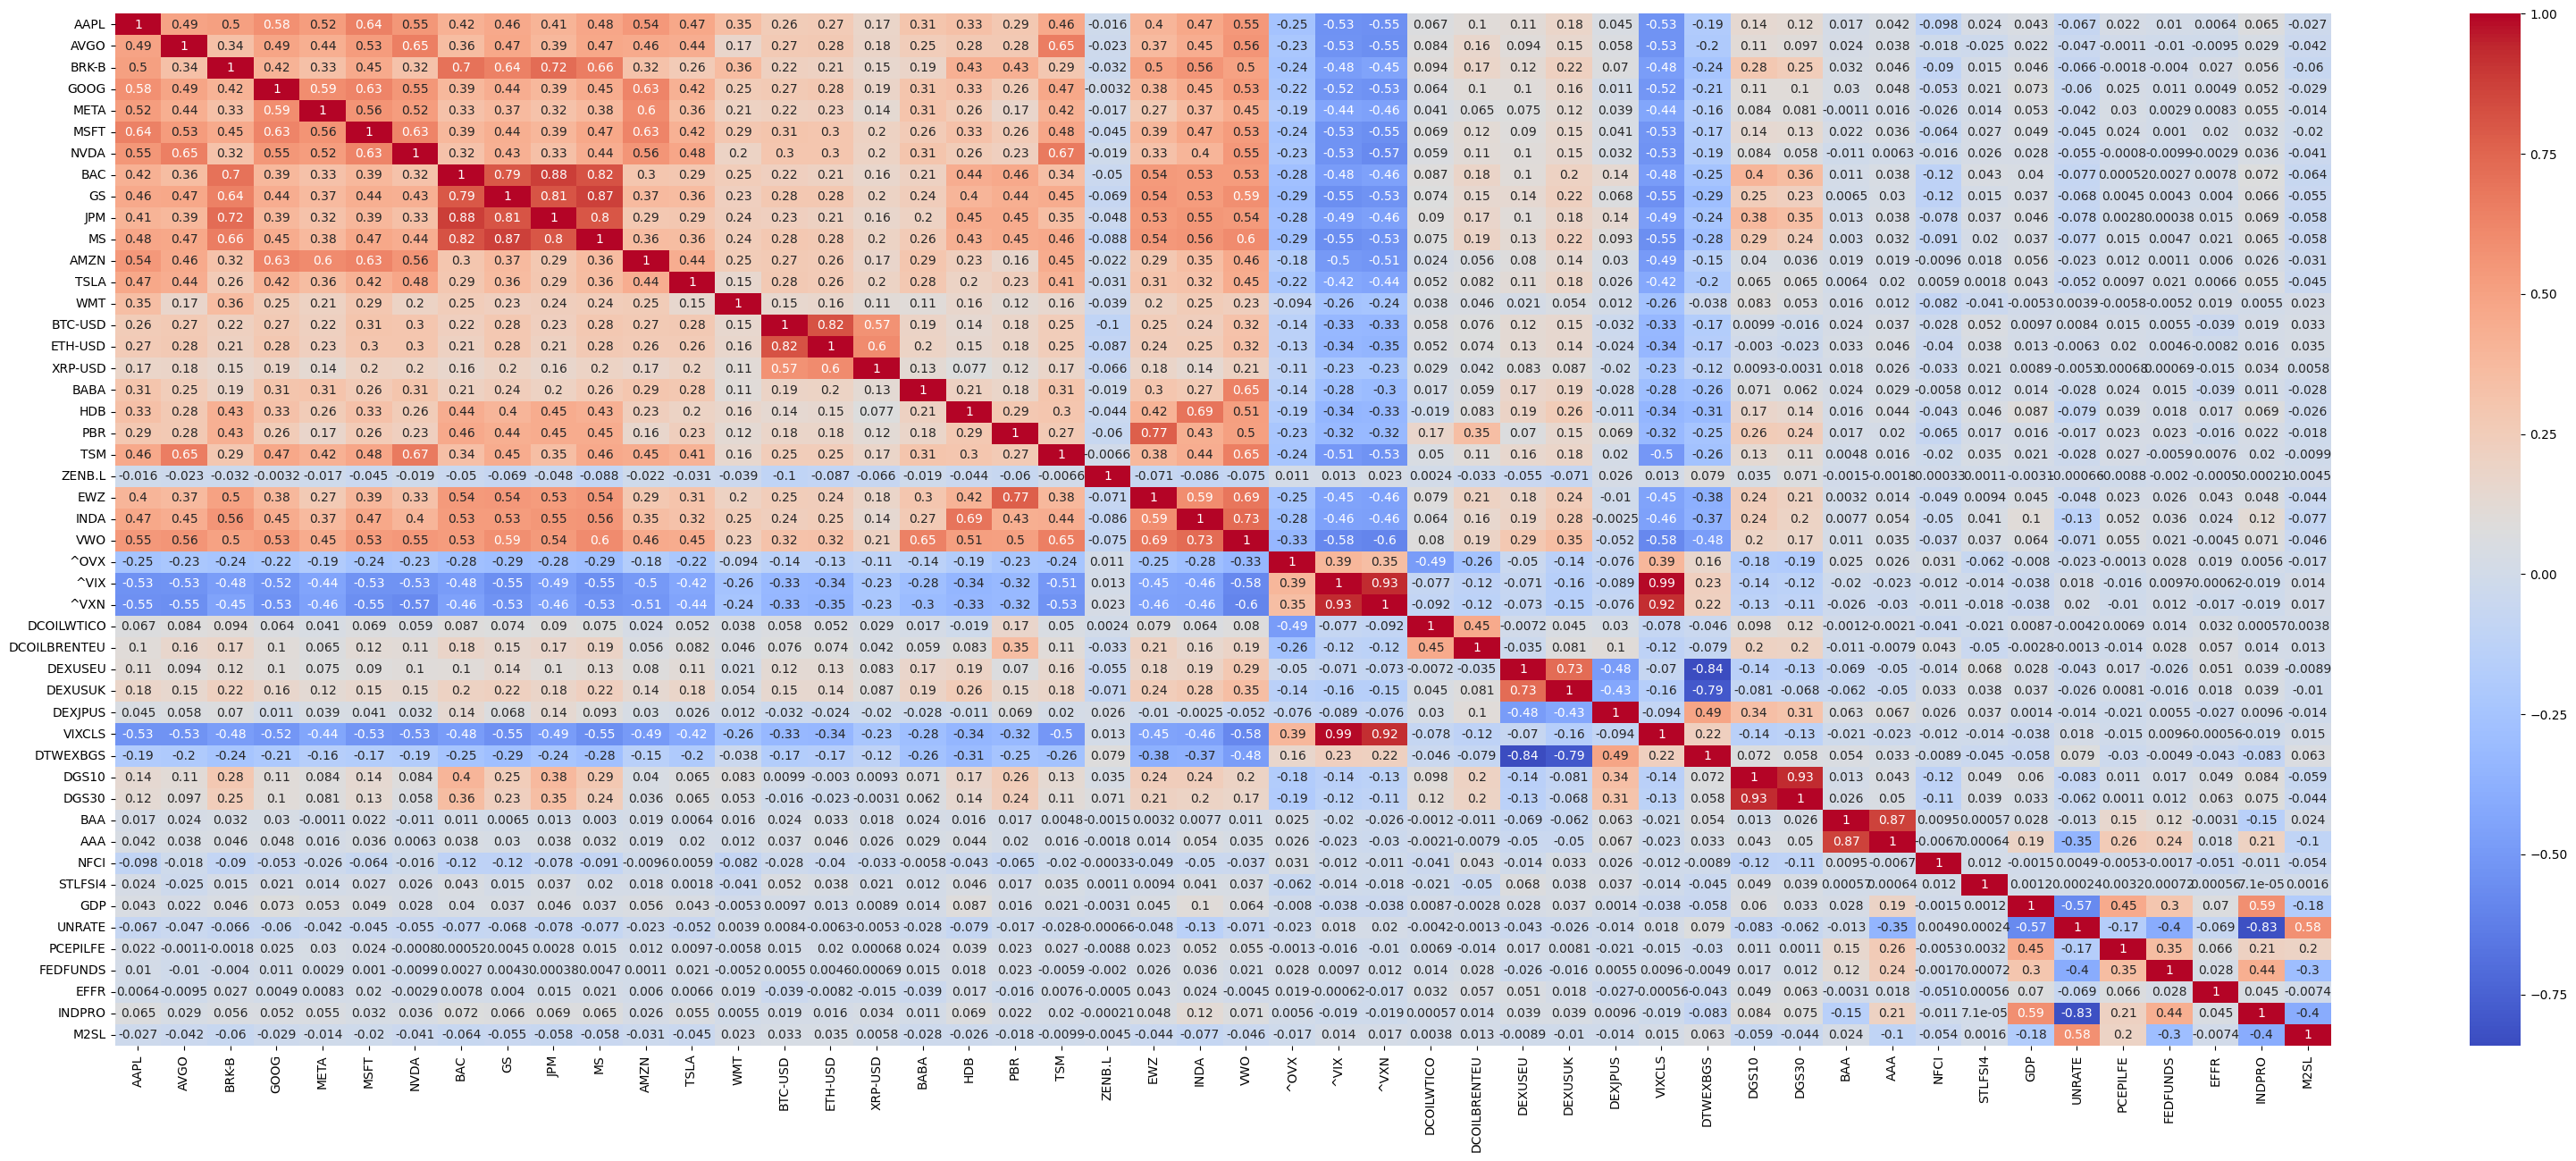

In [ ]:
correlation_matrix = findata.corr()
figure_size = (40, 15)
plt.figure(figsize=figure_size)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
findata.describe()

,AAPL,AVGO,BRK-B,GOOG,META,MSFT,NVDA,BAC,GS,JPM,...,AAA,NFCI,STLFSI4,GDP,UNRATE,PCEPILFE,FEDFUNDS,EFFR,INDPRO,M2SL
count,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,...,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000,2408.000000
mean,0.000748,0.001415,0.000406,0.000832,0.000701,0.000627,0.001881,0.000465,0.000836,0.000595,...,0.000334,0.001700,-1.253795,0.000171,0.000583,0.000092,0.001899,0.002272,0.000013,0.000171
std,0.016450,0.023101,0.010861,0.016954,0.022886,0.015948,0.027208,0.017512,0.017299,0.016077,...,0.010449,0.113557,61.913542,0.003069,0.049207,0.000577,0.054108,0.082419,0.003485,0.002125
min,-0.128647,-0.199129,-0.095921,-0.111008,-0.263901,-0.147390,-0.184521,-0.153973,-0.127053,-0.149649,...,-0.195364,-1.622951,-3038.000000,-0.082430,-0.176471,-0.003240,-0.923077,-0.772727,-0.131878,-0.014025
25%,-0.003488,-0.004738,-0.002613,-0.003489,-0.005234,-0.003655,-0.007006,-0.004233,-0.004119,-0.003236,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.005601,0.008252,0.003998,0.006636,0.007256,0.005634,0.011171,0.005670,0.006623,0.005590,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,0.153289,0.244326,0.116099,0.099709,0.232824,0.155067,0.243697,0.177962,0.175803,0.180125,...,0.127764,4.363636,18.709360,0.087490,2.363636,0.005919,1.500000,3.125000,0.065530,0.064212


In [ ]:
findata.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2409 entries, 2020-01-03 to 2026-08-07
Freq: D
Data columns (total 48 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AAPL          2408 non-null   float64
 1   AVGO          2408 non-null   float64
 2   BRK-B         2408 non-null   float64
 3   GOOG          2408 non-null   float64
 4   META          2408 non-null   float64
 5   MSFT          2408 non-null   float64
 6   NVDA          2408 non-null   float64
 7   BAC           2408 non-null   float64
 8   GS            2408 non-null   float64
 9   JPM           2408 non-null   float64
 10  MS            2408 non-null   float64
 11  AMZN          2408 non-null   float64
 12  TSLA          2408 non-null   float64
 13  WMT           2408 non-null   float64
 14  BTC-USD       2408 non-null   float64
 15  ETH-USD       2408 non-null   float64
 16  XRP-USD       2408 non-null   float64
 17  BABA          2408 non-null   float64
 18  HD

In [ ]:
findata.isnull().sum()

,0
AAPL,1
AVGO,1
BRK-B,1
GOOG,1
META,1
MSFT,1
NVDA,1
BAC,1
GS,1
JPM,1


In [ ]:
findata

,AAPL,AVGO,BRK-B,GOOG,META,MSFT,NVDA,BAC,GS,JPM,...,AAA,NFCI,STLFSI4,GDP,UNRATE,PCEPILFE,FEDFUNDS,EFFR,INDPRO,M2SL
2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-06,0.007968,-0.001496,0.003581,0.024657,0.018834,0.002585,0.004194,-0.001432,0.010234,-0.000795,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-07,-0.004703,-0.003443,-0.004714,-0.000624,0.002164,-0.009118,0.012107,-0.006600,0.006583,-0.017000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-03,-0.017772,0.007578,0.003128,0.044357,0.060229,0.049342,0.029340,0.008555,0.008523,0.002416,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-04,0.019643,0.066109,0.007951,0.007732,-0.003897,0.010581,0.025648,0.006722,0.025237,0.013838,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-05,0.005236,0.000287,0.003151,-0.040549,0.001412,-0.010856,0.034349,0.005564,0.007028,0.004811,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-06,0.004534,0.005475,0.011101,-0.009747,0.001919,0.025438,-0.001049,-0.003953,-0.026217,-0.008184,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
findata.dropna()

,AAPL,AVGO,BRK-B,GOOG,META,MSFT,NVDA,BAC,GS,JPM,...,AAA,NFCI,STLFSI4,GDP,UNRATE,PCEPILFE,FEDFUNDS,EFFR,INDPRO,M2SL
2020-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-06,0.007968,-0.001496,0.003581,0.024657,0.018834,0.002585,0.004194,-0.001432,0.010234,-0.000795,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-07,-0.004703,-0.003443,-0.004714,-0.000624,0.002164,-0.009118,0.012107,-0.006600,0.006583,-0.017000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2020-01-08,0.016086,-0.012474,0.000310,0.007880,0.010138,0.015928,0.001876,0.010110,0.009640,0.007801,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-03,-0.017772,0.007578,0.003128,0.044357,0.060229,0.049342,0.029340,0.008555,0.008523,0.002416,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-04,0.019643,0.066109,0.007951,0.007732,-0.003897,0.010581,0.025648,0.006722,0.025237,0.013838,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-05,0.005236,0.000287,0.003151,-0.040549,0.001412,-0.010856,0.034349,0.005564,0.007028,0.004811,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-08-06,0.004534,0.005475,0.011101,-0.009747,0.001919,0.025438,-0.001049,-0.003953,-0.026217,-0.008184,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Granger Causality & Network theory

This section begins by introducing Granger Causality & Network Theory, defines a function called build_granger_network(), fits a VAR model, performs conditional Granger causality tests between all variables, constructs a directed network, and visualizes it. The notebook reports a network with 48 nodes and 39 directed edges.

What Does "Cause" Mean Here?

This is one of the most misunderstood topics in finance.

Granger Causality does NOT prove real-world causation.

Instead, it asks:

Does knowing yesterday's values of X improve our prediction of Y, beyond what Y's own history already tells us?

Notice the wording.

It says

helps predict

NOT

physically causes

>>>>>>>>>>>>>>>>>>>>>>>>>|

Why Use a VAR Model?

Inside the function, the notebook creates a VAR model, automatically selects an appropriate lag order using an information criterion (defaulting to BIC), fits the model, and checks whether the fitted VAR is stable before continuing.

Why a VAR?

Imagine you're trying to predict Apple.

Should you only use Apple's history?

Probably not.

Maybe

Microsoft helps.
Interest rates help.
Oil helps.
Bitcoin helps.

A VAR model lets all of these variables help explain one another over time.

Think of it as a group conversation rather than each variable speaking alone.
>>>>>>>>>>>>>>>>>>>>>>>>>|

Why Choose Lag Order?

Suppose oil affects airlines.

Does it happen

today?

tomorrow?

next week?

We don't know.

The lag order determines

how far back in time

the model should look.

Too short

↓

Miss information.

Too long

↓

Too much noise.

That's why the notebook chooses the lag order automatically.
>>>>>>>>>>>>>>>>>>>>>>>>>|

Bonferroni Correction

One of my favorite parts.

Most students skip this.

Don't.

The notebook optionally applies a Bonferroni correction, making the significance threshold stricter because it performs many hypothesis tests across pairs of variables.

Imagine flipping a coin.

Probability of getting Heads

50%.

Now imagine

you flip it

10,000 times.

Eventually,

something strange happens by chance.

Exactly the same problem happens in statistics.

If you perform hundreds or thousands of tests,

some will look significant

just by luck.

The Bonferroni correction lowers the significance threshold to reduce these false positives.



Building the Adjacency Matrix

The notebook creates an empty matrix:

adj_matrix = np.zeros(...)

Then,

every time a significant relationship is found,

it records it in that matrix.

Think of it like a giant friendship chart.

|         | Apple | Oil | Bitcoin |
| ------- | ----- | --- | ------- |
| Apple   | 0     | 1   | 0       |
| Oil     | 0     | 0   | 1       |
| Bitcoin | 0     | 0   | 0       |


A "1" means:

"There is a directed relationship."

A "0" means:

"No relationship detected."

Turning the Matrix into a Graph

The notebook uses NetworkX to convert the adjacency matrix into a directed graph, relabels the nodes with the variable names, and later draws the network with arrows and node sizes based on degree centrality.

This is much easier for humans to understand than staring at a giant matrix.

Degree Centrality

Notice this code idea:

degree_centrality

What is that?

Imagine a student.

If

30 classmates

talk to him,

he's important.

If

only one person

talks to him,

less important.

Degree centrality measures

how connected

a node is.

Large nodes in the visualization are the ones with many connections.

Why Hedge Funds Love This

Suppose you discover:

Interest Rates
        ↓
Banks

Banks
      ↓
Technology

Technology
       ↓
Semiconductors

Now,

instead of waiting,

you can anticipate possible market movements based on historically predictive relationships.

That's valuable.

What Did the Notebook Find?

After running the analysis, the notebook reports:

Number of Nodes: 48

Number of Edges: 39

That means:

48 different financial and macroeconomic variables were included.
39 directed predictive links remained after the testing procedure.

It does not mean all variables influence each other.

In fact,

most pairs showed no statistically significant predictive relationship, which is exactly what we'd expect in real financial data.

Real-World Analogy

Imagine a city with 48 people.

Not everyone calls everyone else.

Maybe only 39 meaningful communication lines exist.

That's your financial network.

Why This Comes Before Monte Carlo

Many people think Monte Carlo is just

"Generate random numbers."

Professional quants disagree.

Before simulating the future,

they first ask:

Which markets influence others?
Which assets are connected?
Which variables matter most?
Which relationships are statistically meaningful?

Only then do they simulate future scenarios.

This notebook follows that same philosophy.

In [ ]:
from statsmodels.tools.sm_exceptions import EstimationWarning
import warnings

warnings.simplefilter("ignore", EstimationWarning)


def build_granger_network(
    findata: pd.DataFrame,
    maxlags: int = 10,
    ic: str = "bic",
    alpha: float = 0.05,
    use_bonferroni: bool = True,
    weighted: bool = False
):
    """
    Build a conditional Granger causality network using a multivariate VAR model.

    Parameters
    ----------
    findata : pd.DataFrame
        Time series data (T x N), columns = variables/assets
    maxlags : int
        Maximum lag order for selection
    ic : str
        Information criterion ('aic', 'bic', 'hqic', 'fpe')
    alpha : float
        Significance level
    use_bonferroni : bool
        Whether to apply Bonferroni correction
    weighted : bool
        If True, use -log(p-value) as edge weight

    Returns
    -------
    G : networkx.DiGraph
        Directed Granger causality network
    adj_matrix : np.ndarray
        Adjacency matrix
    results : dict
        Dictionary of p-values for all pairs
    """

    # -----------------------------
    # 1. Data checks & preprocessing
    # -----------------------------
    findata = findata.dropna()

    if not isinstance(findata, pd.DataFrame):
        raise ValueError("findata must be a pandas DataFrame")

    variables = findata.columns
    n_var = len(variables)

    # -----------------------------
    # 2. Lag selection
    # -----------------------------
    model = VAR(findata)
    lag_selection = model.select_order(maxlags=maxlags)

    lag_order = getattr(lag_selection, ic)

    if lag_order is None or lag_order <= 0:
        lag_order = 1

    # -----------------------------
    # 3. Fit VAR model (once)
    # -----------------------------
    model_fitted = model.fit(lag_order)

    if not model_fitted.is_stable():
        print("Warning: VAR model is not stable. Results may be unreliable.")

    # -----------------------------
    # 4. Multiple testing correction
    # -----------------------------
    if use_bonferroni:
        p_threshold = alpha / (n_var * (n_var - 1))
    else:
        p_threshold = alpha

    # -----------------------------
    # 5. Initialize outputs
    # -----------------------------
    adj_matrix = np.zeros((n_var, n_var))
    results = {}

    # -----------------------------
    # 6. Conditional Granger tests
    # -----------------------------
    for i, cause in enumerate(variables):
        for j, effect in enumerate(variables):
            if i == j:
                continue

            try:
                test = model_fitted.test_causality(
                    caused=effect,
                    causing=[cause],
                    kind='f'
                )

                p_value = test.pvalue
                results[(cause, effect)] = p_value

                if p_value < p_threshold:
                    if weighted:
                        adj_matrix[i, j] = -np.log(p_value)
                    else:
                        adj_matrix[i, j] = 1

            except Exception as e:
                # Robust handling for numerical issues
                results[(cause, effect)] = np.nan
                continue

    # -----------------------------
    # 7. Build network
    # -----------------------------
    G = nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

    mapping = {i: var for i, var in enumerate(variables)}
    G = nx.relabel_nodes(G, mapping)

    return G, adj_matrix, results

## The Notebook Builds a Network


Imagine all 48 financial variables.

Drawing every relationship manually would be impossible.

Instead,

we build a network.

What is a Network?

Imagine Facebook.

You

↓

Friends

↓

Friends of Friends

That is a network.

>>>>>>>>>>>>>>>>>>>>>>>>>|

Finance works similarly.

Instead of people,

we have assets.

Oil

↓

Airlines

VIX

   ↓

Technology

Interest Rate

  ↓

Banks

GDP

  ↓

Retail

Each arrow means

"This variable contains predictive information for another variable."

>>>>>>>>>>>>>>>>>>>>>>>>>|

The Language of Network Theory

A network has two important pieces.

1. Nodes

Nodes are simply the things we're studying.

In the notebook,

each node is one financial variable.

For example

Apple
Bitcoin
Oil
GDP
VIX

The notebook ultimately builds a graph with 48 nodes, corresponding to the 48 variables in the dataset.

2. Edges

Edges are the arrows connecting nodes.

Example

Oil

   ↓
   
Airlines

That arrow is an edge.

The notebook found 39 directed edges, meaning 39 statistically significant predictive relationships under its testing procedure.

Number of Nodes: 48
Number of Edges: 40


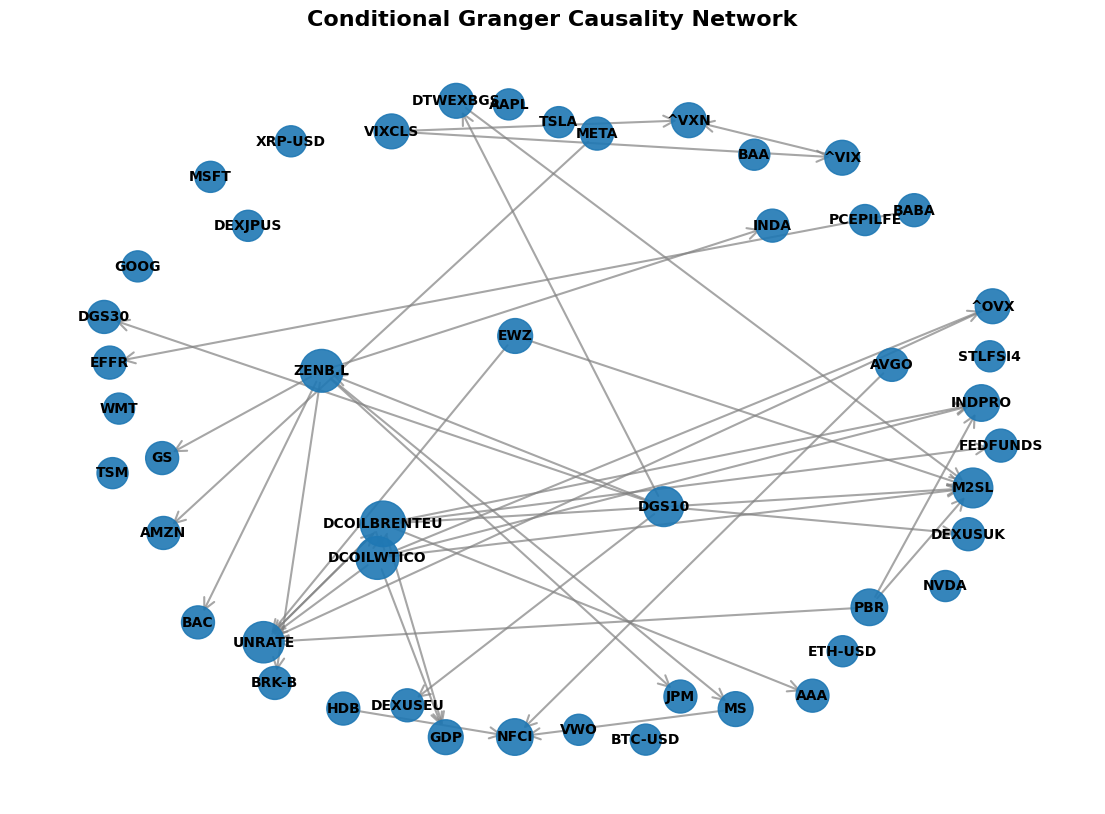

In [ ]:
# =========================
# Create Network
# =========================

G, adj_matrix, results = build_granger_network(findata)

# Create directed graph from adjacency matrix
G = nx.from_numpy_array(
    adj_matrix,
    create_using=nx.DiGraph
)

# Relabel nodes using variable names
mapping = {i: col for i, col in enumerate(findata.columns)}
G = nx.relabel_nodes(G, mapping)

# =========================
# Basic Network Information
# =========================

print(f"Number of Nodes: {G.number_of_nodes()}")
print(f"Number of Edges: {G.number_of_edges()}")

# =========================
# Visualization
# =========================

plt.figure(figsize=(14, 10))

# Positioning algorithm
pos = nx.spring_layout(G, seed=42, k=1.5)

# Node sizes based on degree centrality
degree_centrality = nx.degree_centrality(G)

node_sizes = [
    3000 * degree_centrality[node] + 500
    for node in G.nodes()
]

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.9
)

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle='->',
    arrowsize=20,
    edge_color='gray',
    width=1.5,
    alpha=0.7
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold'
)

# Title
plt.title(
    "Conditional Granger Causality Network",
    fontsize=16,
    fontweight='bold'
)

plt.axis('off')
plt.show()

What is a Market Regime?

A regime is simply

A period where the market behaves in a similar way.

Examples

* **Calm Market**

  * Small movements

  * Low volatility

  * Investors confident

  * Stocks rise steadily

* **Crisis Market**

  * Huge price swings

  * Fear everywhere

  * High volatility

  * Rapid buying and selling

* **Recovery Market**

  * Confidence returns

  * Volatility decreases

  * Stocks begin climbing again

Notice something important.

The rules change depending on the regime.


>>>>>>>>>>>>>>>>>>>>>>>>>>>>|

**Step 1 — Standardization**

The notebook first applies:

StandardScaler()

to all numeric variables before PCA.

Why?

Imagine we have:

| Variable       |   Size |
| -------------- | -----: |
| Apple Return   |   0.02 |
| GDP            | 30,000 |
| Bitcoin Return |   0.05 |


GDP is enormous.

If we don't standardize,

PCA will think GDP is the most important variable simply because its numbers are bigger.

Not because it's more informative.

What Does StandardScaler Do?

It transforms every variable so that

Average = 0

Standard Deviation = 1

Now every variable competes fairly.
>>>>>>>>>>>>>>>>>>>>>>>>>>>>|

**Step 2 — PCA**

PCA means

Principal Component Analysis


Imagine interviewing

48 witnesses.

Many tell almost the same story.

Instead of writing

48 reports,

you summarize everything into

ONE report.

That's PCA.

The notebook starts with

48 variables.

After PCA

↓

1 variable.

This new variable is called

Market_Factor

What Is the Market Factor?

Think of it as

"The overall mood of the financial market."

Instead of watching

Apple

Microsoft

Oil

Bitcoin

Inflation

Interest Rates

GDP

VIX

all separately,

PCA combines their common movements into one number.

>>>>>>>>>>>>>>>>>>>>>>>>>>>>|

Explained Variance

The notebook shows:

Explained Variance Ratio

0.259

It DOES NOT mean

PCA is only

25% accurate.

It means

The first principal component explains about 25.9% of the total variation across all 48 variables.

Imagine reading

48 books.

One summary captures

26%

of all the information.

That's actually impressive to some extent.

>>>>>>>>>>>>>>>>>>>>>>>>>>>>|

**Step 3 — Markov Switching Model**

The notebook fits:

MarkovRegression(...)

with:

k_regimes = 2

Meaning

The model assumes

there are

two hidden market states.

***Notice***

Nobody tells the computer

where crises happened.

The model discovers them.

***Why Is It Called Hidden?***

Imagine walking into a room.

You can't see outside.

Someone walks in

wearing a wet jacket.

Umbrella.

Boots.

You conclude

"It's probably raining."

You never saw the rain.

You inferred it.

That's exactly what a Hidden Markov Model does.

It infers hidden states from observations.

>>>>>>>>>>>>>>>>>>>>>>>>>>>>|

**Step 4 — Regime Probabilities**

The notebook computes:

Regime_Prob

and then assigns:

Regime

0

or

1

based on whether the probability exceeds 0.5.

This is important.

The model doesn't say

Definitely Crisis.

Instead it says

97% chance we're in Regime 1.

Much more realistic.

**Example**

| Probability | Meaning                   |
| ----------- | ------------------------- |
| 0.03        | Almost certainly Regime 0 |
| 0.48        | Uncertain                 |
| 0.90        | Very likely Regime 1      |
| 1.00        | Almost certain Regime 1   |


The notebook creates two visualizations:

The market factor with shaded regions representing one detected regime.
The smoothed probability of being in Regime 1 over time.

Think of it like a weather map.

Instead of

Sunny

Rainy

Storm

The graph shows

Calm Market

vs

High-Probability Regime 1.

***Understanding the Results***

The notebook reports:

Regime 0

Variance ≈ 0.034
Regime 1

Variance ≈ 18.465

This is one of the biggest clues.

Variance measures how much values fluctuate.

A variance of about 18.5 is dramatically larger than 0.034.

That suggests Regime 1 is a much more volatile state than Regime 0.

From the notebook alone, we can confidently say the two regimes have very different volatility characteristics. Interpreting Regime 1 specifically as a "crisis" regime is a reasonable inference, but the notebook itself labels them only as Regime 0 and Regime 1.

**Why Hedge Funds Use This**

Imagine you're managing

$5 billion.

Would you invest the same way when markets are calm

and

when markets become extremely volatile?

No.

A hedge fund might do something like:

*If Regime 0*
  * Hold more equities
  * Take more risk
  * Increase leverage
  
*If Regime 1*
  * Reduce risk
  * Hold more cash
  * Buy protective options
  * Hedge the portfolio

The model isn't predicting prices directly.

It's identifying what type of market environment you're currently in, so investment decisions can adapt.

In [ ]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression


def _information_criterion(res, ic: str):
    """
    Read aic/bic/hqic off a fitted statsmodels results object if available,
    otherwise compute it from the log-likelihood as a fallback (in case the
    installed statsmodels version doesn't expose these attributes directly
    on MarkovSwitchingResults).
    """
    val = getattr(res, ic, None)
    if val is not None:
        return float(val)

    llf = res.llf
    k_params = len(res.params)
    nobs = res.nobs

    if ic == "aic":
        return float(-2 * llf + 2 * k_params)
    elif ic == "bic":
        return float(-2 * llf + k_params * np.log(nobs))
    elif ic == "hqic":
        return float(-2 * llf + 2 * k_params * np.log(np.log(nobs)))
    else:
        raise ValueError(f"Unknown information criterion: {ic}")


def select_markov_regime_order(
    series: pd.Series,
    k_regimes_range=range(2, 5),
    trend: str = 'c',
    switching_variance: bool = True,
    ic: str = 'bic'
):
    """
    Fit a Markov-switching regression for each candidate number of regimes
    in k_regimes_range and pick the one that minimizes the chosen
    information criterion (aic/bic/hqic). BIC is the default because it
    penalizes extra regimes more heavily than AIC, which is generally
    preferred for choosing the number of discrete states in a regime model.

    Returns
    -------
    best_k : int
        The recommended number of regimes.
    scores_df : pd.DataFrame
        aic/bic/hqic/log-likelihood for every k that fit successfully,
        sorted by the chosen criterion (best first).
    """
    rows = []

    for k in k_regimes_range:
        try:
            candidate_model = MarkovRegression(
                series,
                k_regimes=k,
                trend=trend,
                switching_variance=switching_variance
            )
            candidate_res = candidate_model.fit()

            rows.append({
                'k_regimes': k,
                'aic': _information_criterion(candidate_res, 'aic'),
                'bic': _information_criterion(candidate_res, 'bic'),
                'hqic': _information_criterion(candidate_res, 'hqic'),
                'llf': candidate_res.llf,
            })
        except Exception as e:
            print(f"k_regimes={k} failed to fit and was skipped: {e}")
            continue

    if not rows:
        raise RuntimeError("No candidate k_regimes value converged; cannot select a model.")

    scores_df = pd.DataFrame(rows).sort_values(by=ic).reset_index(drop=True)
    best_k = int(scores_df.iloc[0]['k_regimes'])

    return best_k, scores_df

Regime Change Using Markov chain Regression switching method

Explained Variance Ratio:
[0.25794738]


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Regime-count selection (Market_Factor pipeline):
   k_regimes           aic           bic          hqic          llf
0          4  10448.805564  10564.536600  10490.901489 -5204.402782
1          3  10600.146038  10669.584660  10625.403593 -5288.073019
2          2  11085.022208  11119.741519  11097.650986 -5536.511104
Selected k_regimes = 4 (lowest BIC)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                        Markov Switching Model Results                        
Dep. Variable:          Market_Factor   No. Observations:                 2408
Model:               MarkovRegression   Log Likelihood               -5204.403
Date:                Fri, 07 Aug 2026   AIC                          10448.806
Time:                        20:45:26   BIC                          10564.537
Sample:                    01-04-2020   HQIC                         10490.901
                         - 08-07-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1296      0.007    -18.192      0.000      -0.144      -0.116
sigma2         0.0215      0.002     11.629      0.0

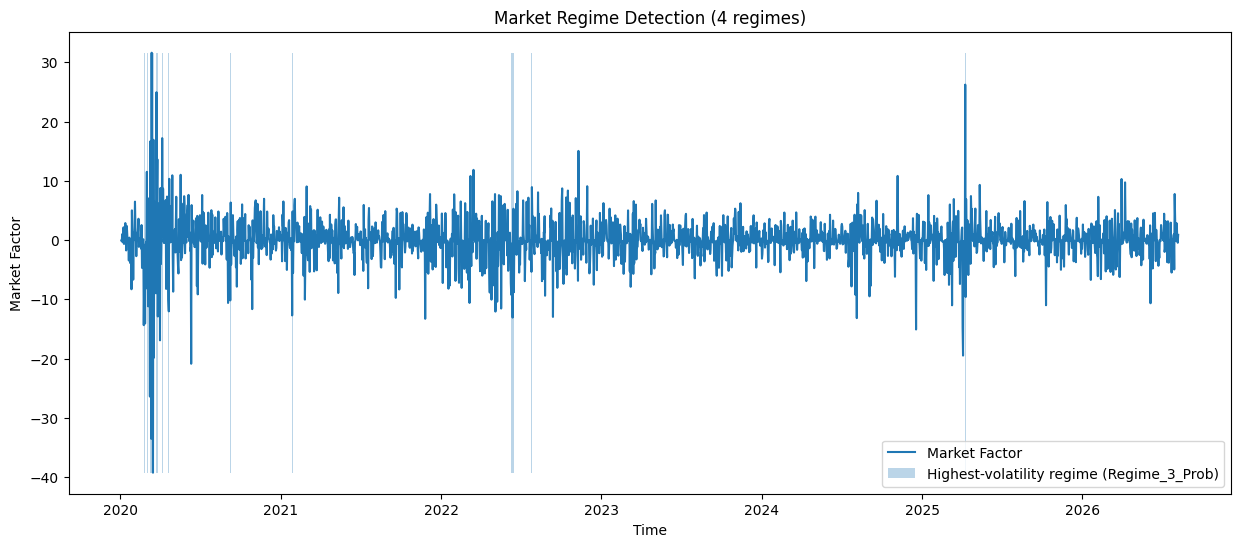

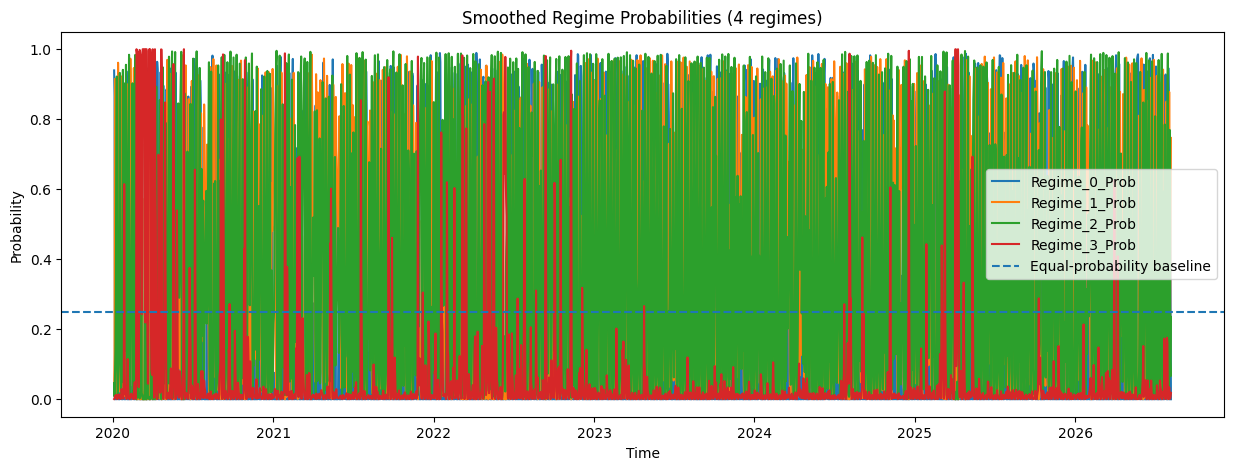

            Market_Factor         Regime
2020-01-04      -0.079677  Regime_0_Prob
2020-01-05      -0.105343  Regime_0_Prob
2020-01-06       1.002480  Regime_1_Prob
2020-01-07      -0.381108  Regime_1_Prob
2020-01-08       1.353339  Regime_1_Prob
...                   ...            ...
2026-08-03       2.879770  Regime_1_Prob
2026-08-04       2.259912  Regime_2_Prob
2026-08-05       0.044478  Regime_0_Prob
2026-08-06      -0.449860  Regime_1_Prob
2026-08-07       0.882168  Regime_1_Prob

[2408 rows x 2 columns]


In [ ]:
# ============================================================
# PRACTICAL REGIME DETECTION PIPELINE
# PCA + MARKOV SWITCHING MODEL
# ============================================================

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# STEP 1 - CLEAN DATA
# ============================================================

# Remove missing values
findata = findata.dropna()

# Keep only numeric columns
findata = findata.select_dtypes(include=[np.number])

# ============================================================
# STEP 2 - STANDARDIZE VARIABLES
# ============================================================

scaler = StandardScaler()

scaled_data = scaler.fit_transform(findata)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=findata.columns,
    index=findata.index
)

# ============================================================
# STEP 3 - PCA (COMBINE ALL VARIABLES)
# ============================================================

# Reduce all variables into one financial factor
pca = PCA(n_components=1)

principal_component = pca.fit_transform(scaled_df)

# Create market/systemic factor
findata['Market_Factor'] = principal_component

# ============================================================
# OPTIONAL - EXPLAINED VARIANCE
# ============================================================

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# ============================================================
# STEP 3b (v2 ADDITION) - SELECT NUMBER OF REGIMES VIA INFORMATION CRITERION
# ============================================================

best_k_market, ic_scores_market = select_markov_regime_order(
    findata['Market_Factor'],
    k_regimes_range=range(2, 5),
    ic='bic'
)

print("Regime-count selection (Market_Factor pipeline):")
print(ic_scores_market)
print(f"Selected k_regimes = {best_k_market} (lowest BIC)")

# ============================================================
# STEP 4 - FIT MARKOV SWITCHING MODEL (using the recommended k_regimes)
# ============================================================

model = MarkovRegression(
    findata['Market_Factor'],
    k_regimes=best_k_market,
    trend='c',
    switching_variance=True
)

results = model.fit()

# ============================================================
# STEP 5 - MODEL SUMMARY
# ============================================================

print(results.summary())

# ============================================================
# STEP 6 - EXTRACT REGIME PROBABILITIES (generalized to any number of regimes)
# ============================================================

regime_probs_market = pd.DataFrame(results.smoothed_marginal_probabilities)
regime_probs_market.columns = [f'Regime_{i}_Prob' for i in range(regime_probs_market.shape[1])]
regime_probs_market.index = findata.index

# Most likely regime at each point in time
findata['Regime'] = regime_probs_market.idxmax(axis=1)

# Label whichever regime has the highest Market_Factor volatility as the "stress"/crisis regime,
# purely for shading the chart below -- this works for any number of regimes, not just 2.
regime_vol_market = findata.groupby('Regime')['Market_Factor'].std()
crisis_regime_market = regime_vol_market.idxmax()

# ============================================================
# STEP 7 - VISUALIZE REGIMES
# ============================================================

fig, ax = plt.subplots(figsize=(15,6))

# Plot market factor
ax.plot(
    findata.index,
    findata['Market_Factor'],
    label='Market Factor'
)

# Shade the highest-volatility regime
ax.fill_between(
    findata.index,
    findata['Market_Factor'].min(),
    findata['Market_Factor'].max(),
    where=findata['Regime'] == crisis_regime_market,
    alpha=0.3,
    label=f'Highest-volatility regime ({crisis_regime_market})'
)

plt.title(f'Market Regime Detection ({best_k_market} regimes)')
plt.xlabel('Time')
plt.ylabel('Market Factor')
plt.legend()

plt.show()

# ============================================================
# STEP 8 - PLOT REGIME PROBABILITIES (all regimes, not just one)
# ============================================================

plt.figure(figsize=(15,5))

for col in regime_probs_market.columns:
    plt.plot(findata.index, regime_probs_market[col], label=col)

plt.axhline(
    1.0 / best_k_market,
    linestyle='--',
    label='Equal-probability baseline'
)

plt.title(f'Smoothed Regime Probabilities ({best_k_market} regimes)')
plt.xlabel('Time')
plt.ylabel('Probability')
plt.legend()

plt.show()

# ============================================================
# STEP 9 - VIEW FINAL OUTPUT
# ============================================================

print(
    findata[
        ['Market_Factor', 'Regime']
    ]
)

In [ ]:

print("Regime membership counts (Market_Factor pipeline):")
print(findata['Regime'].value_counts().sort_index())

Regime membership counts (Market_Factor pipeline):
Regime
Regime_0_Prob    746
Regime_1_Prob    708
Regime_2_Prob    859
Regime_3_Prob     95
Name: count, dtype: int64


In [ ]:
findata = findata.drop(['Regime'], axis = 1)

###GARCH MODEL

GARCH (Generalized Autoregressive Conditional Heteroskedasticity)

The notebook now begins a Multivariate Financial Regime + Volatility Pipeline, introducing GARCH after completing the regime detection stage.

Let's understand it from the ground up.

The Big Picture

Imagine you are watching the ocean.

Some days:

Small waves.

Easy sailing.

Other days:

Huge waves.

Very dangerous.


When the ocean becomes rough,

it usually stays rough for a while.

Likewise,

when it is calm,

it usually stays calm for a while.

Financial markets behave exactly the same way.

Does Market Risk Stay Constant?

Many beginners assume:

Risk today = Risk tomorrow

Reality:

Calm
↓

Calm

↓

Calm

↓

Panic

↓

Panic

↓

Panic

↓

Recovery

↓

Calm

Risk changes over time.

What is Volatility?

Volatility simply means

How much prices move.

Example:

Stock A

100

101

100

99

100

Very small movements.

Low volatility.

Stock B

100

150

80

170

60

Huge movements.

High volatility.



The Biggest Discovery in Finance

Researchers noticed something strange.

Big price movements

are usually followed by

Big price movements.

Small movements

are usually followed by

Small movements.

This phenomenon is called

Volatility Clustering

Imagine rain.

If today rains heavily,

tomorrow

probably rains too.

If today is sunny,

tomorrow

is often sunny.

Weather clusters.

Financial volatility clusters too.

Example

Imagine this sequence.

0.1%

0.2%

0.1%

0.3%

Very calm.

Then suddenly

5%

4%

6%

3%

Chaos.

Notice something?

Once chaos starts,

it doesn't disappear immediately.

This is exactly what GARCH models.

**Why Normal Statistics Fail**

Suppose I ask:

"What is tomorrow's volatility?"

Old models answer:

Same as yesterday.

Or

Constant forever.

Reality?

Markets don't behave like that.

Volatility changes every day.

What Does GARCH Mean?

Let's break it down.

Generalized

Works in many situations.

AutoRegressive

Uses yesterday's information.

Conditional

Today's estimate depends on today's conditions.

Heteroskedasticity

A scary word.

Let's simplify.

"Hetero"

means

Different.

"Skedasticity"

means

Variance.

So

Heteroskedasticity simply means

The variance changes over time.



The Famous GARCH Formula

A standard GARCH(1,1) model can be written as

$$ \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2 $$



We'll decode every piece.

σ²

Tomorrow's volatility.

That's what we're trying to predict.

ω (Omega)

The baseline volatility.

Imagine

Even when nothing unusual happens,

the market still has some natural level of risk.

That's ω.

α (Alpha)

Yesterday's shock.

Suppose yesterday

the market suddenly crashed.

Should tomorrow's volatility increase?

Absolutely.

Alpha measures

how strongly yesterday's surprise affects today.

β (Beta)

Memory.

Markets have memory.

If yesterday

volatility was already high,

today

it's probably still high.

Beta measures

how long volatility persists.

Imagine Cooking Soup

Tomorrow's soup depends on

Today's ingredients.

The soup recipe is

Base soup

+

Yesterday's spice

+

Yesterday's flavor

Exactly what GARCH does.

**What Does the Notebook Do?**

Typically, a GARCH workflow in this context involves:

Selecting a return series.
Estimating time-varying volatility.
Comparing predicted volatility with observed market behavior.
Feeding volatility estimates into later risk or simulation models.


***Why Quants Love GARCH***

Imagine you're a risk manager at Goldman Sachs.

A client asks:

"How risky will tomorrow be?"

If yesterday looked like this:

📉📉📉📉📉

You shouldn't answer

"Risk is normal."

Instead,

GARCH recognizes

Yesterday was chaotic.

Tomorrow

risk is likely still elevated.

**Why This Matters for Options**

Remember the Black-Scholes model?

One assumption is

Constant volatility.

Professional traders know

that's unrealistic.

Many option pricing systems therefore replace constant volatility assumptions with models that allow volatility to evolve over time, and GARCH is one of the classic approaches for forecasting that evolution.

How This Connects to Markov Models

Notice what we've built so far.



***Markov asks***

What market environment are we in?

Example

Calm

or

High Volatility


***GARCH asks***

Given this environment, how volatile should tomorrow be?

Different questions.

Both important.

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>|

Real Hedge Fund Workflow

Imagine you're managing $10 billion.

Every morning

your system asks

Step 1

Which regime?

Calm
Step 2

Expected volatility?

Low
Decision

Increase stock allocation.

Next month

System says

Regime

High Volatility

GARCH predicts

Very High Risk

Decision

Reduce leverage.

Buy hedges.

Increase cash.

That's exactly how quantitative risk systems are designed.

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>|

***Why GARCH Comes Before Monte Carlo***

Now we're almost ready for simulation.

Think about it.

Suppose we simulate tomorrow's stock price.

Should we always use

10% volatility?

No.

Some days

market volatility is

8%.

Other days

40%.

GARCH estimates the appropriate volatility so the Monte Carlo simulation can produce more realistic future scenarios.

Explained Variance Ratio:
[0.27309131]


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Regime-count selection (Systemic_Factor pipeline):
   k_regimes           aic           bic          hqic          llf
0          4  10636.142422  10751.873459  10678.238347 -5298.071211
1          3  10787.175134  10856.613756  10812.432689 -5381.587567
2          2  11272.051303  11306.770614  11284.680080 -5630.025652
Selected k_regimes = 4 (lowest BIC)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                        Markov Switching Model Results                        
Dep. Variable:        Systemic_Factor   No. Observations:                 2408
Model:               MarkovRegression   Log Likelihood               -5298.071
Date:                Fri, 07 Aug 2026   AIC                          10636.142
Time:                        20:46:03   BIC                          10751.873
Sample:                    01-04-2020   HQIC                         10678.238
                         - 08-07-2026                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1348      0.007    -18.199      0.000      -0.149      -0.120
sigma2         0.0233      0.002     11.906      0.0

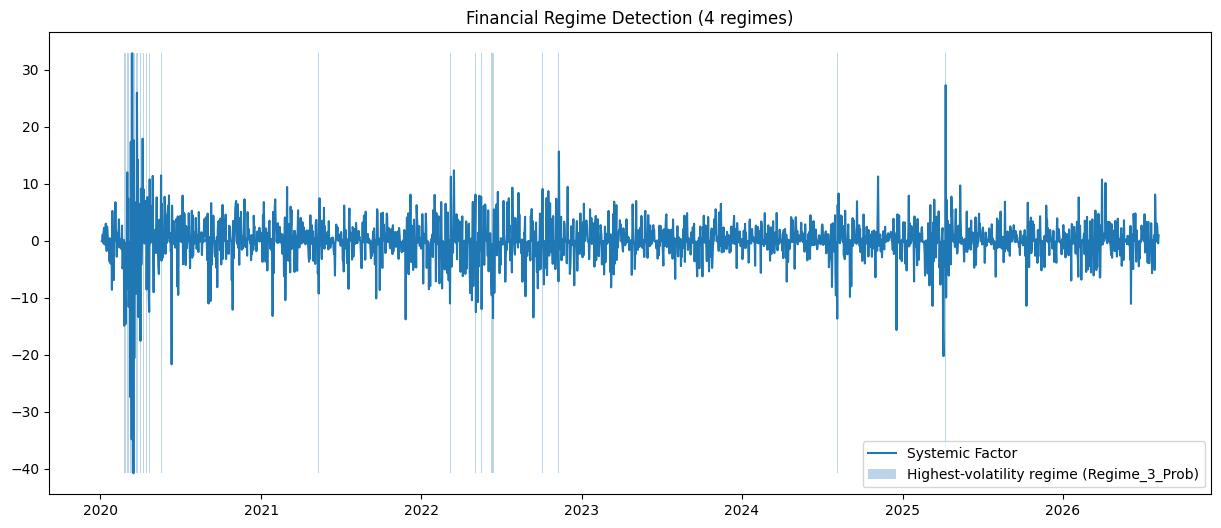

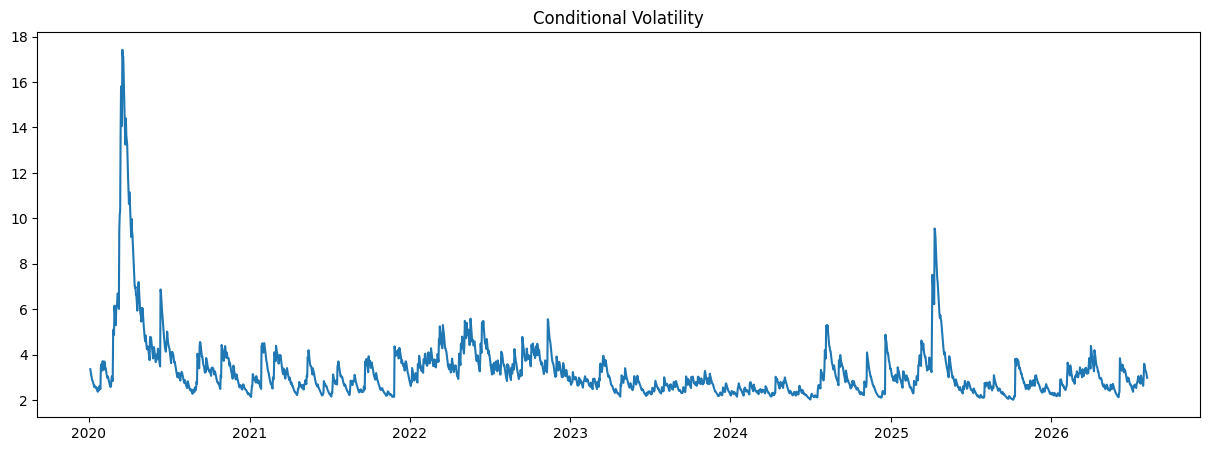

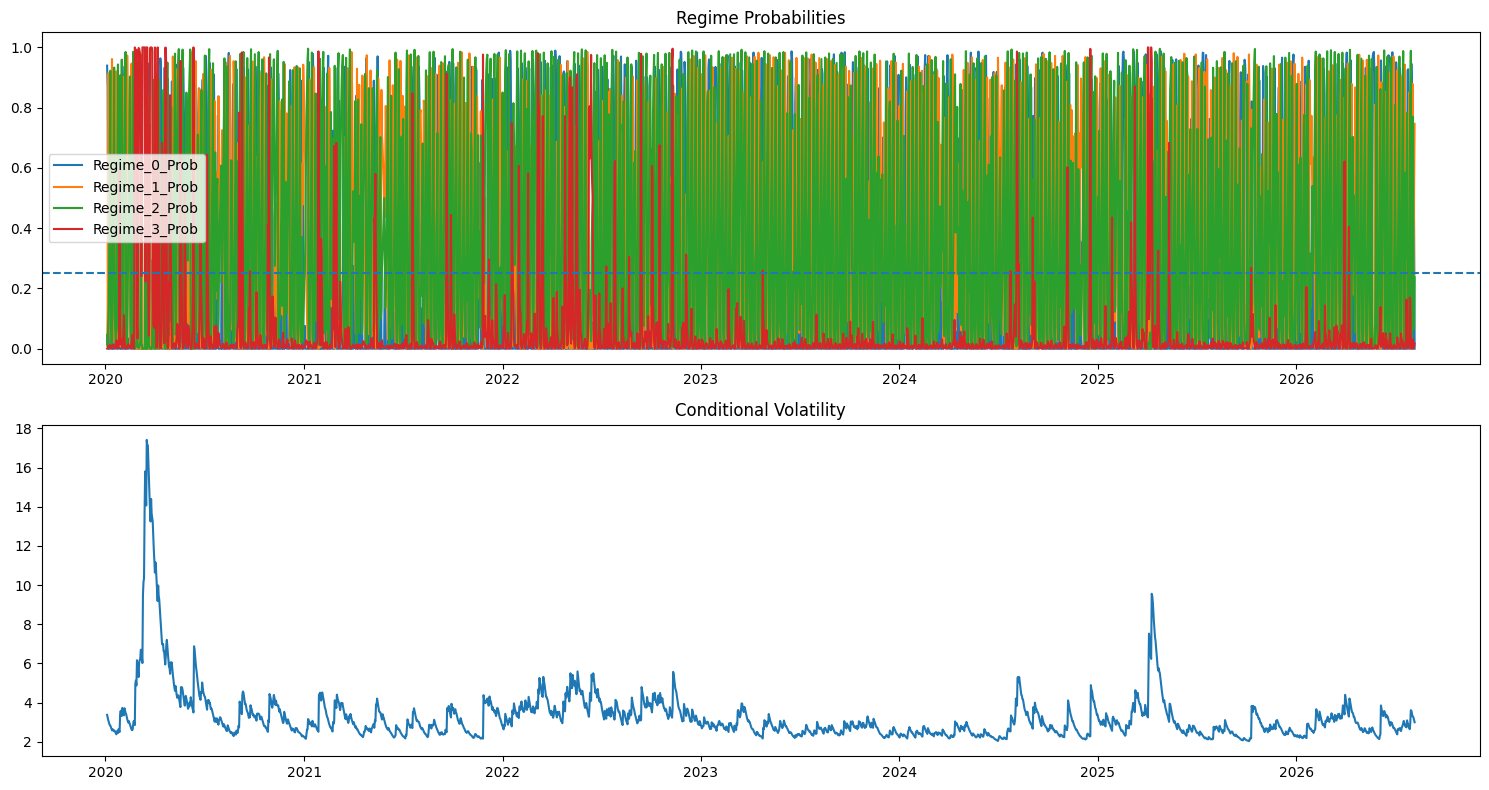

In [ ]:
# ============================================================
# MULTIVARIATE FINANCIAL REGIME + VOLATILITY PIPELINE
# ============================================================

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

!pip install arch
from arch import arch_model

# ============================================================
# STEP 1 - CLEAN DATA
# ============================================================

findata = findata.dropna()

# Keep numeric variables only
findata = findata.select_dtypes(include=[np.number])

# ============================================================
# STEP 2 - STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

scaled = scaler.fit_transform(findata)

scaled_df = pd.DataFrame(
    scaled,
    columns=findata.columns,
    index=findata.index
)

# ============================================================
# STEP 3 - PCA
# COMBINE ALL VARIABLES INTO ONE FACTOR
# ============================================================

pca = PCA(n_components=1)

findata['Systemic_Factor'] = pca.fit_transform(scaled_df)

# Explained variance
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

# ============================================================
# STEP 3b (v2 ADDITION) - SELECT NUMBER OF REGIMES VIA INFORMATION CRITERION
# ============================================================

best_k_systemic, ic_scores_systemic = select_markov_regime_order(
    findata['Systemic_Factor'],
    k_regimes_range=range(2, 5),
    ic='bic'
)

print("Regime-count selection (Systemic_Factor pipeline):")
print(ic_scores_systemic)
print(f"Selected k_regimes = {best_k_systemic} (lowest BIC)")

# ============================================================
# STEP 4 - MARKOV SWITCHING MODEL (using the recommended k_regimes)
# ============================================================

ms_model = MarkovRegression(
    findata['Systemic_Factor'],
    k_regimes=best_k_systemic,
    trend='c',
    switching_variance=True
)

ms_results = ms_model.fit()

print(ms_results.summary())

# ============================================================
# STEP 5 - REGIME PROBABILITIES (generalized to any number of regimes)
# ============================================================

regime_probs_systemic = pd.DataFrame(ms_results.smoothed_marginal_probabilities)
regime_probs_systemic.columns = [f'Regime_{i}_Prob' for i in range(regime_probs_systemic.shape[1])]
regime_probs_systemic.index = findata.index

findata['Regime'] = regime_probs_systemic.idxmax(axis=1)

regime_vol_systemic = findata.groupby('Regime')['Systemic_Factor'].std()
crisis_regime_systemic = regime_vol_systemic.idxmax()

# ============================================================
# STEP 6 - GARCH MODEL
# ============================================================

garch = arch_model(
    findata['Systemic_Factor'],
    vol='GARCH',
    p=1,
    q=1,
    mean='constant'
)

garch_results = garch.fit(disp='off')

print(garch_results.summary())

# ============================================================
# STEP 7 - CONDITIONAL VOLATILITY
# ============================================================

findata['Volatility'] = (
    garch_results.conditional_volatility
)

# ============================================================
# STEP 8 - VISUALIZE REGIMES
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    findata.index,
    findata['Systemic_Factor'],
    label='Systemic Factor'
)

plt.fill_between(
    findata.index,
    findata['Systemic_Factor'].min(),
    findata['Systemic_Factor'].max(),
    where=findata['Regime'] == crisis_regime_systemic,
    alpha=0.3,
    label=f'Highest-volatility regime ({crisis_regime_systemic})'
)

plt.title(f'Financial Regime Detection ({best_k_systemic} regimes)')

plt.legend()

plt.show()

# ============================================================
# STEP 9 - VOLATILITY PLOT
# ============================================================

plt.figure(figsize=(15,5))

plt.plot(
    findata.index,
    findata['Volatility']
)

plt.title('Conditional Volatility')

plt.show()

# ============================================================
# STEP 10 - REGIME VS VOLATILITY
# ============================================================

fig, ax = plt.subplots(2, 1, figsize=(15,8))

# Regime probabilities (all regimes)
for col in regime_probs_systemic.columns:
    ax[0].plot(findata.index, regime_probs_systemic[col], label=col)

ax[0].axhline(1.0 / best_k_systemic, linestyle='--')
ax[0].set_title('Regime Probabilities')
ax[0].legend()

# Conditional volatility
ax[1].plot(
    findata.index,
    findata['Volatility']
)

ax[1].set_title('Conditional Volatility')

plt.tight_layout()
plt.show()

##Monte Carlo Portfolio Simulation

This chapter begins by selecting the assets that will make up the portfolio, removing missing values, generating correlated simulated returns, optimizing portfolio weights, and then estimating the portfolio's risk using Monte Carlo Value at Risk (VaR).

Let's break down every idea.

The Big Picture

Imagine I ask you:

"What will Apple's return be tomorrow?"

Can you know exactly?

No.

Nobody can.

So instead of predicting one future...

Quants simulate millions of possible futures.

That's Monte Carlo.

Why is it called Monte Carlo?

It is named after the famous casino district in Monaco.

Why?

Because casinos deal with

randomness
probability
chance

Monte Carlo simulations also use randomness—but in a controlled mathematical way.

***Choosing the Portfolio***

The notebook creates a portfolio from 20 assets, including technology stocks, banks, international companies, cryptocurrencies, and retail firms.

Some examples are:

Apple

Microsoft

Nvidia

Tesla

Amazon

Bitcoin

Ethereum

JPMorgan

Goldman Sachs

Walmart

***Why not just use one stock?***

Imagine investing

100%

of your money

into Tesla.

If Tesla crashes...

You're in trouble.

Instead,

spread your money across many assets.

This is called

Diversification

***Step 2 — Removing Missing Values***

The notebook removes rows with missing observations before simulation.

Why?

Monte Carlo relies on matrices.

Matrices cannot easily handle missing numbers.

***Step 3 — Generating Correlated Returns***

Now we arrive at one of the most important functions:

generate_correlated_returns(...)

This function is the engine of the simulation.

Let's understand it line by line.

First
corr_matrix = historical_returns.corr().values

What is this?

It's the correlation matrix.

Imagine three friends.

Apple

Microsoft

Tesla

If Apple usually rises with Microsoft,

their correlation is high.

If Apple moves opposite another asset,

their correlation may be negative.

The correlation matrix summarizes these relationships.

Example:

|           | Apple | Microsoft | Tesla |
| --------- | ----: | --------: | ----: |
| Apple     |  1.00 |      0.82 |  0.45 |
| Microsoft |  0.82 |      1.00 |  0.39 |
| Tesla     |  0.45 |      0.39 |  1.00 |

Why Is This Important?

Suppose we ignored correlation.

Our simulation might produce:

Apple ↑ 10%

Microsoft ↓ 15%

Even though historically

they often move together.

That wouldn't be very realistic.

***Step 4 — Cholesky Decomposition***

The notebook then computes

L = np.linalg.cholesky(corr_matrix)

This is one of the most elegant tricks in quantitative finance.

***What is Cholesky?***

Imagine three dancers.

If everyone dances independently,

they bump into each other.

But if they practice together,

their movements become coordinated.

Cholesky takes independent random numbers and transforms them into correlated random numbers.

Why Do We Need It?

We first generate independent random shocks:

Z = np.random.standard_normal(...)

These are like students taking an exam in separate rooms—no influence on each other.

But financial assets are connected.

So Cholesky acts like a choreographer, introducing realistic relationships while preserving randomness.

The Mathematics (Simple Version)

Suppose

$$ Z \sim N(0,I) $$

means independent random variables.

Multiply them by the Cholesky matrix:

$$ X = ZL^T $$

Now

\(X\)

has approximately the correlation structure observed in the historical data.

This is why Cholesky is used so often in portfolio simulations.


***Step 5 — Simulating Millions of Futures***

The notebook calls:

generate_correlated_returns(5000000, portfolio_returns)

That means it generates 5,000,000 simulated return scenarios for the portfolio assets.

Why So Many?

Suppose you toss a coin twice.

Results:

Heads

Heads

You might wrongly think

the coin always lands on Heads.

Now toss it

1,000,000 times.

The estimate becomes much more reliable.

The same principle applies to financial simulations.

Why This Matters

Instead of asking

"What happens tomorrow?"

Monte Carlo asks

"What could happen tomorrow?"

And it answers that question millions of times.

How This Connects to Earlier Chapters

***Notice how every previous chapter contributes here:***

Returns → provide the historical behavior.

Correlation → tells us how assets move together.

Stationarity → makes the statistical modeling more reliable.

GARCH → estimates changing volatility

Nothing we've learned has been wasted.

It all feeds into this simulation engine.

***Why Hedge Funds Use Monte Carlo***

Imagine you're managing

$20 billion.

You don't ask:

"What's the most likely outcome?"

You ask:

What's the best-case outcome?
What's the worst-case outcome?
How often could I lose money?
How bad could those losses become?

Monte Carlo lets you explore an entire distribution of possible futures, not just one prediction.

In [ ]:
portfolio_returns = findata[
    ['AAPL','AMZN','AVGO','BABA','BRK-B',
     'BTC-USD','ETH-USD','GOOG','GS',
     'HDB','JPM','META','MSFT','NVDA',
     'PBR','TSLA','TSM',
     'WMT','XRP-USD','ZENB.L']
]

In [ ]:
portfolio_returns.dropna(inplace=True)

/tmp/ipykernel_4319/1199659898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  portfolio_returns.dropna(inplace=True)


In [ ]:
def generate_correlated_returns(n_samples: int, historical_returns: pd.DataFrame) -> pd.DataFrame:
    """
    Generate correlated return samples using Cholesky decomposition
    (multivariate normal, whole-history correlation matrix).
    """

    # Correlation matrix
    corr_matrix = historical_returns.corr().values

    # Cholesky factor
    L = np.linalg.cholesky(corr_matrix)

    # Independent standard normal samples
    Z = np.random.standard_normal((n_samples, corr_matrix.shape[0]))

    # Correlated samples
    simulated = Z @ L.T

    return pd.DataFrame(simulated, columns=historical_returns.columns)

In [ ]:
generate_correlated_returns(5000000,portfolio_returns)

,AAPL,AMZN,AVGO,BABA,BRK-B,BTC-USD,ETH-USD,GOOG,GS,HDB,JPM,META,MSFT,NVDA,PBR,TSLA,TSM,WMT,XRP-USD,ZENB.L
0,0.496714,0.151911,0.757229,1.607182,0.122478,0.072299,1.048299,0.979228,0.093042,0.812115,-0.117988,0.210987,0.600953,-0.601771,-1.184048,-0.269458,-0.533632,0.551074,-0.322038,-1.390058
1,1.465649,0.601581,0.728303,-0.911013,0.243147,0.292826,-0.373545,0.847075,-0.093467,-0.098357,-0.353700,1.902333,0.983601,0.144639,0.599275,-0.577475,0.393489,-1.382321,-1.202500,0.273500
2,0.738467,0.543069,0.306308,-0.037003,-0.899267,-0.622072,-0.721582,0.998049,-0.101428,-1.633681,-0.380321,0.224180,-0.082011,0.735088,0.568993,1.233222,-0.119088,-0.438570,-0.122898,1.110358
3,-0.479174,-0.415052,-1.207414,-1.380688,0.327169,0.951086,0.610990,0.254673,0.161001,-0.618349,0.352020,0.781303,-0.185285,0.485579,-2.356818,0.278905,-0.397231,-0.159705,0.596033,-1.928667
4,-0.219672,0.181902,1.213616,-0.384360,-0.659454,-0.391730,0.237040,0.336406,-0.441069,0.270642,-0.405407,0.872289,-0.205143,0.264313,-0.561127,-1.134132,0.657646,0.026094,-0.076297,-0.121404
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,-0.188369,0.374093,-0.089613,-2.011123,-0.495407,-0.056967,0.213838,0.687334,-1.699241,-1.151310,-1.340378,0.606676,0.184719,-0.991143,-1.047262,-1.203838,-0.244899,-0.880836,-0.091732,-0.105570
4999996,-0.249394,-0.461282,-0.669335,-1.310926,0.451160,0.088880,-1.124921,-1.040553,-0.357168,-0.472589,-0.346058,-1.079822,-0.694041,-1.111594,0.304366,-0.036847,-0.805925,1.006002,-0.705844,0.420724
4999997,1.544076,1.046362,0.789131,-1.510450,1.876516,0.825788,0.367904,0.714168,1.006545,-0.734981,1.037423,0.506825,1.131203,0.718163,0.493792,0.144992,1.433269,0.205372,1.603653,-1.266540
4999998,-1.078518,-0.607735,-0.188334,0.315049,0.062399,0.847757,0.131785,-0.690669,0.113796,-0.110508,0.038250,0.128234,-0.258111,-0.505726,-0.998744,-1.108861,0.869913,-0.387328,0.119456,-0.050757


You're now entering one of the most practical sections in the entire notebook. If Monte Carlo answered:

"What are all the possible futures?"

this chapter answers:

***"Given those possible futures, how should I invest my money?"***

This is the science of Portfolio Optimization, and it's used every day by asset managers, pension funds, hedge funds, and quantitative investment firms.

From this point, the notebook introduces functions for computing portfolio returns, covariance matrices, minimum-variance weights, Value at Risk (VaR), Expected Shortfall (CVaR), diversification metrics, and risk contributions before applying them to the simulated portfolios.

**Chapter 8 — Portfolio Optimization**
The Big Picture

Imagine you have ₦1,000,000.

You want to invest it.

You have these choices:

Apple

Microsoft

Bitcoin

Tesla

JPMorgan

The question isn't:

"Which stock is best?"

The better question is:

"How much money should I put into each one?"

That is portfolio optimization.

Why Not Invest Everything in One Asset?

Imagine your friend says:

"Tesla is amazing! Put all your money there!"

Sounds exciting...

Until Tesla falls 30%.

You've now lost 30% of everything.

Instead, professional investors spread their investments.

This is called asset allocation.



Step 1 — Portfolio Return

The notebook computes portfolio returns by combining the asset returns with a vector of portfolio weights.

Mathematically,

$$ R_p = \sum_{i=1}^{n} w_i R_i $$

where:

\(R_p\) = portfolio return
\(w_i\) = weight of asset \(i\)
\(R_i\) = return of asset \(i\)
Example

Suppose:

| Asset     | Weight | Return |
| --------- | -----: | -----: |
| Apple     |    50% |    10% |
| Microsoft |    30% |     8% |
| Tesla     |    20% |    20% |

Portfolio return

$$ 0.5(10\%) + 0.3(8\%) + 0.2(20\%) $$

=

5%

2.4%

4%

=

11.4%

***Notice something important.***

The portfolio return is a weighted average.



**Step 2 — Portfolio Risk**

Returns alone aren't enough.

Two portfolios may both earn 10%.

But one may experience huge swings,

while the other is much steadier.

Professional investors care about both.

Risk is commonly measured using the covariance matrix, which tells us how assets move together.

***Understanding Covariance***

Correlation tells us whether two assets move together.

Covariance tells us the direction and magnitude of those joint movements.

Imagine:

Apple rises.

Microsoft rises.

Positive covariance.

Apple rises.

Gold falls.

Negative covariance.

***Why Is Covariance So Important?***

Imagine you own:

Airline stocks

Oil companies

Oil becomes expensive.

Airlines may struggle.

Oil companies may benefit.

Owning both can reduce overall portfolio risk because they don't always move in the same direction.

This is the mathematical foundation of diversification.

***The Covariance Matrix***

The notebook computes a covariance matrix from the historical returns before optimization.

Example:

|           | Apple | Microsoft | Tesla |
| --------- | ----: | --------: | ----: |
| Apple     | 0.040 |     0.030 | 0.020 |
| Microsoft | 0.030 |     0.050 | 0.018 |
| Tesla     | 0.020 |     0.018 | 0.090 |


Notice:

Tesla has the largest variance.

That suggests Tesla is more volatile.

**Step 3 — Minimum Variance Portfolio**

One of the notebook's key functions computes minimum variance weights, and the fixed version also adds an optional long-only alternative while keeping the original unconstrained version unchanged.

***What Does "Minimum Variance" Mean?***

Imagine two bridges.

Bridge A

Very shaky.

Bridge B

Very stable.

If your goal is safety,

which do you choose?

Bridge B.

A minimum variance portfolio is the investment equivalent.

It chooses weights that make the overall portfolio volatility as low as possible.

The Mathematics (Intuition)

Portfolio variance is

$$ \sigma_p^2 = w^T \Sigma w $$

where:

\(w\) = vector of portfolio weights
\(\Sigma\) = covariance matrix

Don't worry about memorizing the equation.

The important idea is:

The risk depends on:

Each asset's own volatility.
How every pair of assets moves together.
Why Some Weights Become Negative

Sometimes optimization produces:

| Asset | Weight |
| ----- | -----: |
| Apple |   140% |
| Tesla |   -40% |



"What does -40% mean?"

It means short selling.

What Is Short Selling?

Normally,

you buy a stock,

hoping it rises.

Short selling means

you profit if the stock falls.

The optimizer sometimes chooses negative weights because mathematically they can reduce portfolio variance.

That's why the notebook also includes a long-only version for investors who don't want short positions.






In [ ]:
def calculate_minimum_variance_weights(portfolio_returns: pd.DataFrame) -> pd.Series:
    """
    Compute minimum variance portfolio weights.

    NOTE: this is an unconstrained solution -- weights can be negative
    (implying a short position) or greater than 1. See
    calculate_minimum_variance_weights_long_only below for a
    no-shorting, fully-invested alternative.
    """

    cov_matrix = portfolio_returns.cov().values
    inv_cov = np.linalg.inv(cov_matrix)
    ones = np.ones(len(cov_matrix))

    weights = inv_cov @ ones / (ones.T @ inv_cov @ ones)

    return pd.Series(weights, index=portfolio_returns.columns)

In [ ]:
def calculate_minimum_variance_weights_long_only(returns: pd.DataFrame) -> pd.Series:
    """
    Compute minimum variance portfolio weights with long-only (no short
    selling) and fully-invested (weights sum to 1) constraints.
    """
    from scipy.optimize import minimize

    cov_matrix = returns.cov().values
    n = cov_matrix.shape[0]

    def portfolio_variance(w):
        return w @ cov_matrix @ w

    constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    bounds = tuple((0.0, 1.0) for _ in range(n))
    w0 = np.repeat(1.0 / n, n)

    result = minimize(
        portfolio_variance,
        w0,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        raise RuntimeError(f"Long-only optimization failed: {result.message}")

    return pd.Series(result.x, index=returns.columns)

In [ ]:
calculate_minimum_variance_weights(portfolio_returns)

,0
AAPL,-0.020383
AMZN,0.017237
AVGO,0.003073
BABA,0.015750
BRK-B,0.132332
BTC-USD,0.027932
ETH-USD,-0.012942
GOOG,-0.001315
GS,0.011124
HDB,0.033751


**Step 4 — Value at Risk (VaR)**

Now comes one of the most famous risk measures in finance.

The notebook computes Value at Risk (VaR) from the simulated portfolio returns.

What Is VaR?

Imagine I ask:

"What's the most I expect to lose on a normal bad day?"

VaR answers:

"With X% confidence, losses shouldn't exceed this amount."

Example

Suppose

95% VaR

=

₦50,000

Meaning:

On 95% of days,

you expect losses to be less than ₦50,000.

There is still a 5% chance that losses will be worse.

Common Misunderstanding

VaR does not say:

"You'll only lose ₦50,000."

It says:

"₦50,000 is the threshold that only the worst 5% of outcomes exceed."





In [ ]:
def calculate_portfolio_var(
    simulated_returns: pd.DataFrame,
    weights,
    confidence_levels: list
) -> dict:
    """
    Compute Monte Carlo Value at Risk (VaR) for a portfolio.
    """

    w = weights.values if isinstance(weights, pd.Series) else np.asarray(weights)

    portfolio_returns = simulated_returns.values @ w

    var_results = {
        alpha: -np.percentile(portfolio_returns, (1 - alpha) * 100)
        for alpha in confidence_levels
    }

    return {
        "portfolio_returns": portfolio_returns,
        "portfolio_mean": portfolio_returns.mean(),
        "portfolio_std": portfolio_returns.std(),
        "VaR": var_results
    }

In [ ]:
calculate_portfolio_var(generate_correlated_returns(5000000,portfolio_returns),calculate_minimum_variance_weights(portfolio_returns), confidence_levels=[0.95, 0.99])

{'portfolio_returns': array([ 0.03768297, -0.41304559, -0.2635304 , ..., -0.47070269,
        -0.26005677, -0.96219449]),
 'portfolio_mean': np.float64(-0.00041995568584080284),
 'portfolio_std': np.float64(0.7046124651239003),
 'VaR': {0.95: np.float64(1.159824693085762),
  0.99: np.float64(1.6387419762889217)}}

In [ ]:
print("Standard Deviation of Asset Returns:")
print(portfolio_returns.std())

Standard Deviation of Asset Returns:
AAPL       0.016450
AMZN       0.018722
AVGO       0.023101
BABA       0.025578
BRK-B      0.010861
BTC-USD    0.031292
ETH-USD    0.041930
GOOG       0.016954
GS         0.017299
HDB        0.017082
JPM        0.016077
META       0.022886
MSFT       0.015948
NVDA       0.027208
PBR        0.025390
TSLA       0.033996
TSM        0.020606
WMT        0.012177
XRP-USD    0.053591
ZENB.L     0.005960
dtype: float64


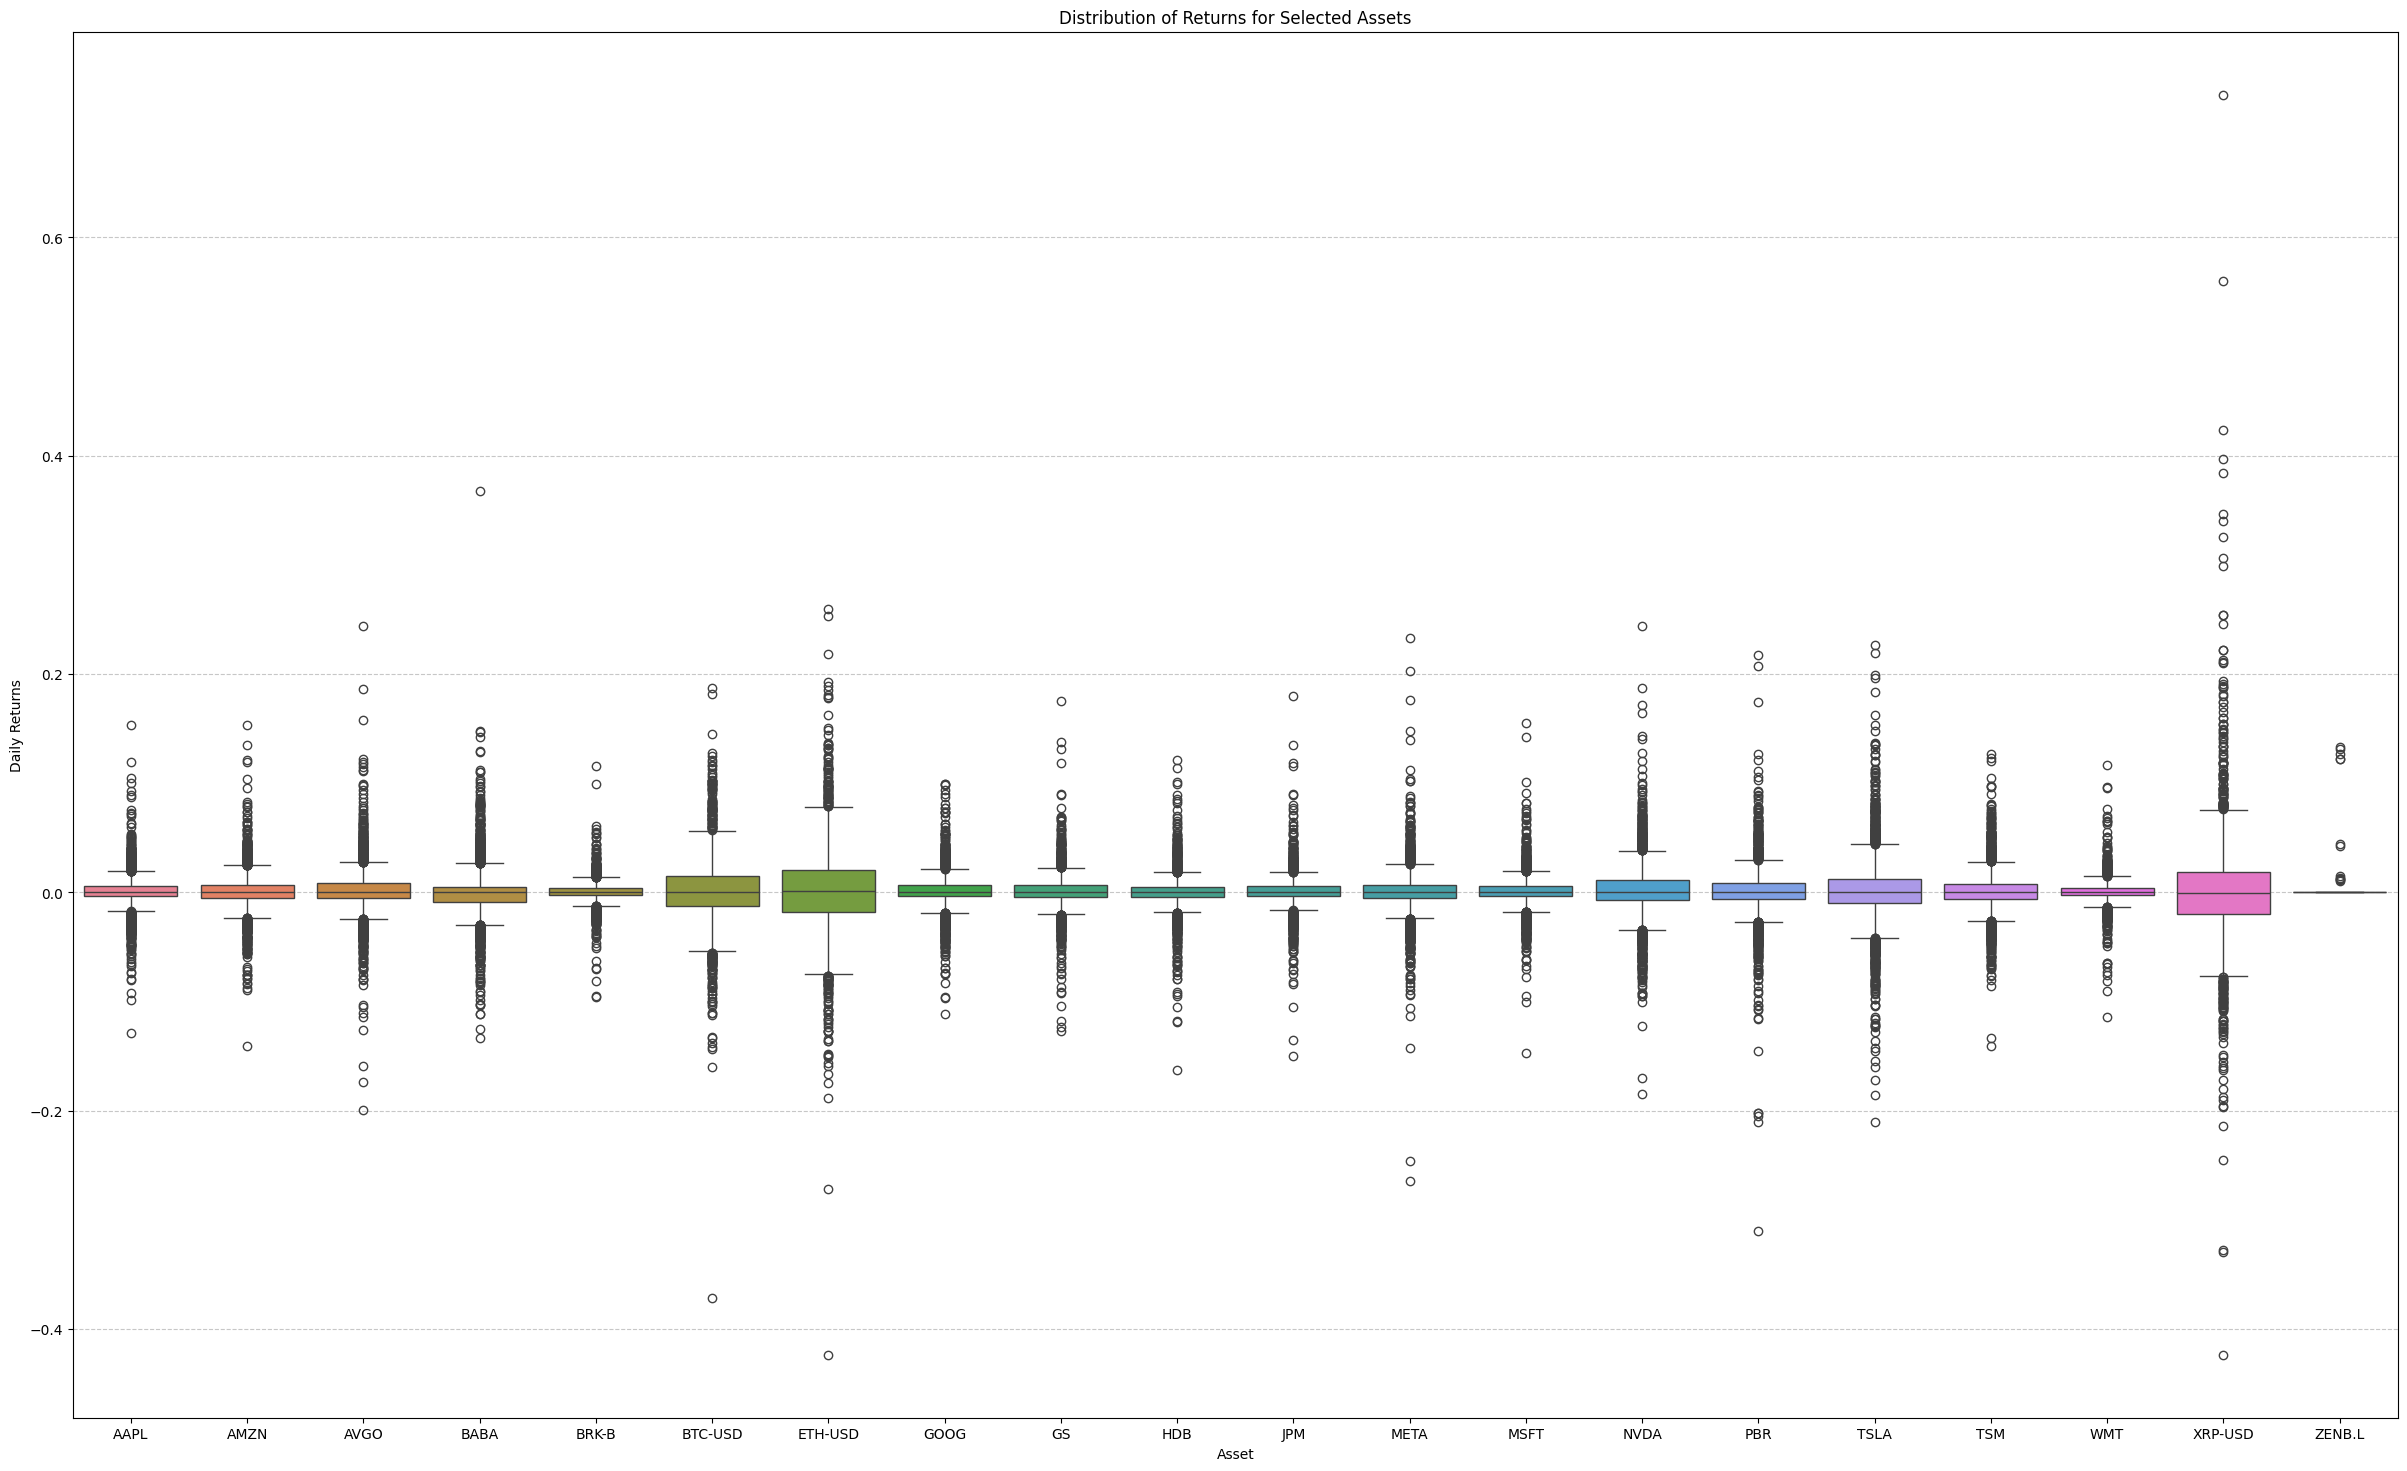

In [ ]:
figure_size = (30, 18)
plt.figure(figsize=figure_size)
sns.boxplot(data=portfolio_returns[['AAPL','AMZN','AVGO','BABA','BRK-B','BTC-USD','ETH-USD','GOOG','GS','HDB','JPM','META','MSFT','NVDA','PBR','TSLA','TSM','WMT','XRP-USD','ZENB.L']])
plt.title('Distribution of Returns for Selected Assets')
plt.ylabel('Daily Returns')
plt.xlabel('Asset')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Step 5 — Expected Shortfall (CVaR)**

The notebook also computes Expected Shortfall, also called Conditional Value at Risk (CVaR).

This asks:

"If I end up in that worst 5%, how bad are those losses on average?"

Example

Suppose

95% VaR

=

₦50,000

Worst losses are

₦60,000

₦70,000

₦90,000

₦150,000

CVaR is the average of those extreme losses.

It tells us how severe the tail of the loss distribution really is.

Why Professionals Prefer CVaR

Imagine two portfolios.

Both have

95% VaR

=

₦50,000

Portfolio A

Worst loss

₦55,000

Portfolio B

Worst loss

₦300,000

Same VaR.

Very different tail risk.

CVaR captures that difference.

***Step 6 — Diversification Metrics***

The notebook also measures the effective number of assets and the marginal contribution to risk.

These answer questions like:

Is my portfolio truly diversified?
Which asset contributes the most to total risk?

Sometimes you own 20 assets but 80% of your risk comes from just three of them.

These metrics help uncover that.

***How Hedge Funds Use This***

A portfolio manager doesn't simply ask:

"Which stock will rise?"

Instead, they ask:

How much should I allocate to each asset?

What is my total portfolio risk?

How much could I lose in a bad scenario?

Which positions contribute the most risk?

Am I diversified enough?

Those are exactly the questions this section of the notebook is designed to answer.

How This Connects to Earlier Chapters

Look how everything fits together:

Historical Data
  
   ↓

Returns

  ↓

Correlation

  ↓

Covariance
        
  ↓

Monte Carlo Scenarios

  ↓

Portfolio Optimization

  ↓
  
VaR & CVaR

Every chapter supports the next.

In [ ]:
def calculate_expected_shortfall(
    portfolio_returns: np.ndarray,
    confidence_level: float
) -> float:
    """
    Compute Expected Shortfall (CVaR).
    """

    var_threshold = -np.percentile(portfolio_returns, (1 - confidence_level) * 100)
    tail_losses = portfolio_returns[portfolio_returns <= -var_threshold]

    return -tail_losses.mean()

In [ ]:
calculate_expected_shortfall(portfolio_returns, confidence_level=0.95)

,0
AAPL,0.047985
AMZN,0.049747
AVGO,0.053359
BABA,0.051627
BRK-B,0.053319
BTC-USD,0.057102
ETH-USD,0.062484
GOOG,0.048702
GS,0.053043
HDB,0.056556


In [ ]:
def var_backtest(
    portfolio_returns: np.ndarray,
    var_value: float
) -> int:
    """
    Count VaR exceedances.
    """

    return np.sum(portfolio_returns <= -var_value)

In [ ]:
_weights = calculate_minimum_variance_weights(portfolio_returns)
_historical_portfolio_returns = portfolio_returns.values @ _weights.values
_historical_var_95 = -np.percentile(_historical_portfolio_returns, 5)

var_backtest(_historical_portfolio_returns, _historical_var_95)

np.int64(121)

In [ ]:
def effective_number_of_assets(weights) -> float:
    """
    Compute Effective Number of Assets (ENB).
    """

    w = weights.values if isinstance(weights, pd.Series) else np.asarray(weights)
    return 1.0 / np.sum(w ** 2)

In [ ]:
effective_number_of_assets(calculate_minimum_variance_weights(portfolio_returns))

np.float64(2.004238230957125)

In [ ]:
def marginal_contribution_to_risk(
    returns: pd.DataFrame,
    weights
) -> np.ndarray:
    """
    Compute Marginal Contribution to Risk (MCR).
    """

    w = weights.values if isinstance(weights, pd.Series) else np.asarray(weights)
    cov_matrix = returns.cov().values

    portfolio_std = np.sqrt(w.T @ cov_matrix @ w)
    mcr = (cov_matrix @ w) / portfolio_std

    return mcr

In [ ]:
marginal_contribution_to_risk(portfolio_returns,calculate_minimum_variance_weights(portfolio_returns))

array([0.00479845, 0.00479845, 0.00479845, 0.00479845, 0.00479845,
       0.00479845, 0.00479845, 0.00479845, 0.00479845, 0.00479845,
       0.00479845, 0.00479845, 0.00479845, 0.00479845, 0.00479845,
       0.00479845, 0.00479845, 0.00479845, 0.00479845, 0.00479845])

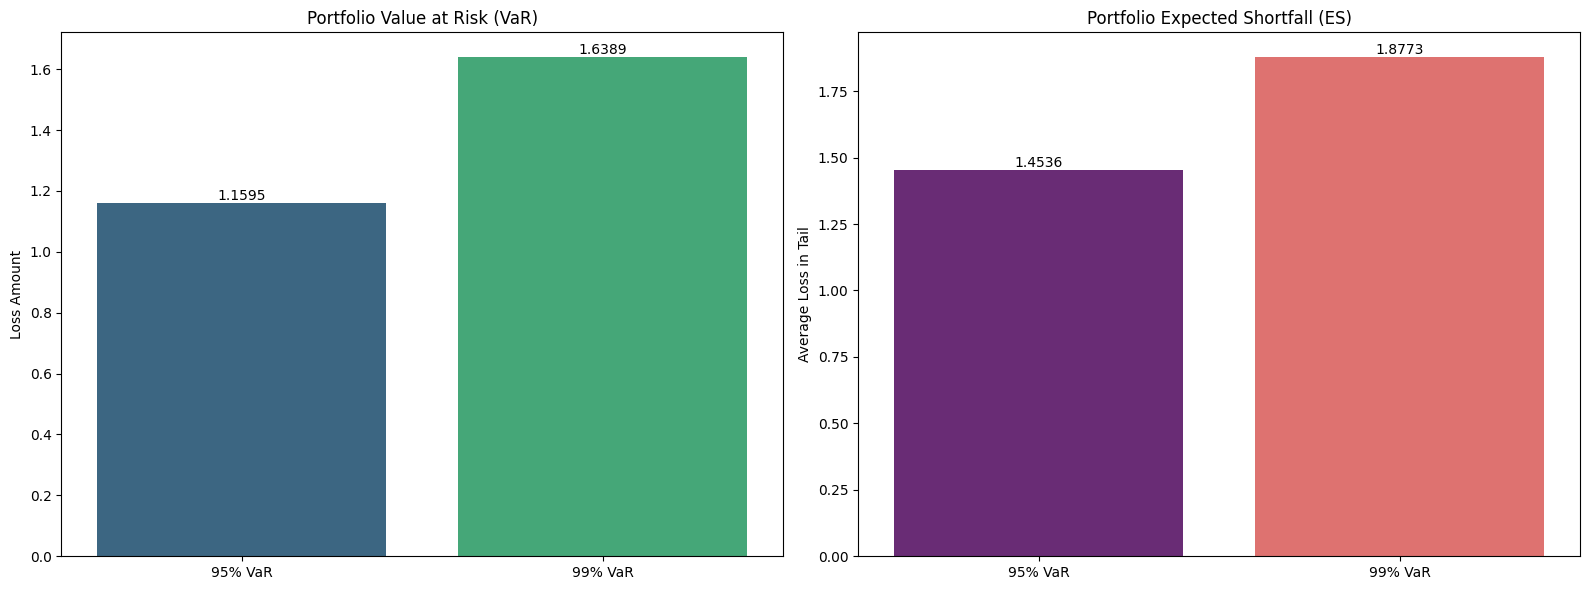

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get portfolio simulated returns and VaR from the previously defined function
simulated_portfolio_data = calculate_portfolio_var(
    generate_correlated_returns(5000000, portfolio_returns),
    calculate_minimum_variance_weights(portfolio_returns),
    confidence_levels=[0.95, 0.99]
)

portfolio_simulated_returns = simulated_portfolio_data['portfolio_returns']
var_95 = simulated_portfolio_data['VaR'][0.95]
var_99 = simulated_portfolio_data['VaR'][0.99]

# Calculate Expected Shortfall for the portfolio
es_95 = calculate_expected_shortfall(portfolio_simulated_returns, confidence_level=0.95)
es_99 = calculate_expected_shortfall(portfolio_simulated_returns, confidence_level=0.99)

# Create the subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VaR Plot
confidence_labels = ['95% VaR', '99% VaR']
var_values = [var_95, var_99]
sns.barplot(x=confidence_labels, y=var_values, ax=axes[0], palette='viridis', hue=confidence_labels, legend=False)
axes[0].set_title('Portfolio Value at Risk (VaR)')
axes[0].set_ylabel('Loss Amount')
for index, value in enumerate(var_values):
    axes[0].text(index, value, f'{value:.4f}', ha='center', va='bottom')

# Expected Shortfall Plot
es_values = [es_95, es_99]
sns.barplot(x=confidence_labels, y=es_values, ax=axes[1], palette='magma', hue=confidence_labels, legend=False)
axes[1].set_title('Portfolio Expected Shortfall (ES)')
axes[1].set_ylabel('Average Loss in Tail')
for index, value in enumerate(es_values):
    axes[1].text(index, value, f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
def estimate_t_degrees_of_freedom(returns: pd.DataFrame, min_df: float = 3.0, max_df: float = 30.0) -> float:
    """
    Rough method-of-moments estimate of Student-t degrees of freedom from
    average excess kurtosis across all columns (pandas' .kurt() is already
    excess kurtosis, i.e. 0 for a normal distribution). For a Student-t
    distribution, excess kurtosis = 6 / (df - 4) for df > 4, so
    df = 4 + 6 / excess_kurtosis. Clipped to [min_df, max_df] since sample
    kurtosis is a noisy estimator, especially with fewer observations.
    """
    excess_kurtosis = returns.kurt().mean()
    excess_kurtosis = max(excess_kurtosis, 0.1)
    df = 4 + 6 / excess_kurtosis
    return float(np.clip(df, min_df, max_df))


def generate_correlated_returns_advanced(
    n_samples: int,
    historical_returns: pd.DataFrame,
    regime_labels: pd.Series = None,
    current_regime=None,
    vol_scale: float = 1.0,
    df: float = None,
):
    """
    Regime-conditional, volatility-scaled, fat-tailed version of
    generate_correlated_returns.

    - If regime_labels and current_regime are given, the correlation matrix
      is estimated using only the rows where regime_labels == current_regime
      (falls back to the full sample if that regime has too little history
      to estimate a stable correlation matrix).
    - vol_scale multiplies every simulated shock (e.g. pass the ratio of
      today's GARCH conditional volatility to its historical average).
    - Shocks are drawn from a multivariate Student-t distribution (via the
      normal / chi-square mixture representation) instead of a multivariate
      normal, so the simulated tails are fatter. If df is None, it is
      estimated from the data's own excess kurtosis.

    Returns
    -------
    simulated : pd.DataFrame
    df_used : float
    n_obs_used_for_corr : int
    """
    if regime_labels is not None and current_regime is not None:
        aligned_labels = regime_labels.reindex(historical_returns.index)
        mask = aligned_labels == current_regime
        data_for_corr = historical_returns.loc[mask.fillna(False)]
        if len(data_for_corr) < historical_returns.shape[1] + 5:


            data_for_corr = historical_returns
    else:
        data_for_corr = historical_returns

    if df is None:
        df = estimate_t_degrees_of_freedom(data_for_corr)

    corr_matrix = data_for_corr.corr().values
    L = np.linalg.cholesky(corr_matrix)

    n_assets = corr_matrix.shape[0]
    Z = np.random.standard_normal((n_samples, n_assets))
    correlated_normal = Z @ L.T

    chi2_draws = np.random.chisquare(df, size=n_samples)
    t_scaling = np.sqrt(df / chi2_draws)

    simulated = correlated_normal * t_scaling[:, None] * vol_scale

    return pd.DataFrame(simulated, columns=historical_returns.columns), df, len(data_for_corr)

In [ ]:



aligned_regime = findata['Regime'].reindex(portfolio_returns.index)
aligned_volatility = findata['Volatility'].reindex(portfolio_returns.index)

current_regime_now = aligned_regime.dropna().iloc[-1]
vol_scale_now = aligned_volatility.iloc[-1] / aligned_volatility.mean()

print(f"Current regime (Systemic_Factor pipeline): {current_regime_now}")
print(f"Current volatility scale (latest GARCH vol / historical average GARCH vol): {vol_scale_now:.3f}")

Current regime (Systemic_Factor pipeline): Regime_1_Prob
Current volatility scale (latest GARCH vol / historical average GARCH vol): 0.917


In [ ]:
N_COMPARISON_SAMPLES = 5000000

advanced_simulated_returns, t_df_used, n_obs_used = generate_correlated_returns_advanced(
    N_COMPARISON_SAMPLES,
    portfolio_returns,
    regime_labels=aligned_regime,
    current_regime=current_regime_now,
    vol_scale=vol_scale_now,
)

print(f"Student-t degrees of freedom used: {t_df_used:.2f}")
print(f"Observations used to estimate the regime-conditional correlation matrix: {n_obs_used} (of {len(portfolio_returns)} total)")



comparison_weights = calculate_minimum_variance_weights(portfolio_returns)

assets_alone_data = calculate_portfolio_var(
    generate_correlated_returns(N_COMPARISON_SAMPLES, portfolio_returns),
    comparison_weights,
    confidence_levels=[0.95, 0.99]
)

all_factors_data = calculate_portfolio_var(
    advanced_simulated_returns,
    comparison_weights,
    confidence_levels=[0.95, 0.99]
)

assets_alone_es_95 = calculate_expected_shortfall(assets_alone_data['portfolio_returns'], confidence_level=0.95)
assets_alone_es_99 = calculate_expected_shortfall(assets_alone_data['portfolio_returns'], confidence_level=0.99)
all_factors_es_95 = calculate_expected_shortfall(all_factors_data['portfolio_returns'], confidence_level=0.95)
all_factors_es_99 = calculate_expected_shortfall(all_factors_data['portfolio_returns'], confidence_level=0.99)

print("Assets alone:        VaR95={:.4f}  VaR99={:.4f}  ES95={:.4f}  ES99={:.4f}".format(
    assets_alone_data['VaR'][0.95], assets_alone_data['VaR'][0.99], assets_alone_es_95, assets_alone_es_99))
print("All factors considered: VaR95={:.4f}  VaR99={:.4f}  ES95={:.4f}  ES99={:.4f}".format(
    all_factors_data['VaR'][0.95], all_factors_data['VaR'][0.99], all_factors_es_95, all_factors_es_99))

Student-t degrees of freedom used: 4.20
Observations used to estimate the regime-conditional correlation matrix: 705 (of 2408 total)
Assets alone:        VaR95=1.1592  VaR99=1.6400  ES95=1.4542  ES99=1.8793
All factors considered: VaR95=1.3882  VaR99=2.4049  ES95=2.0600  ES99=3.3081


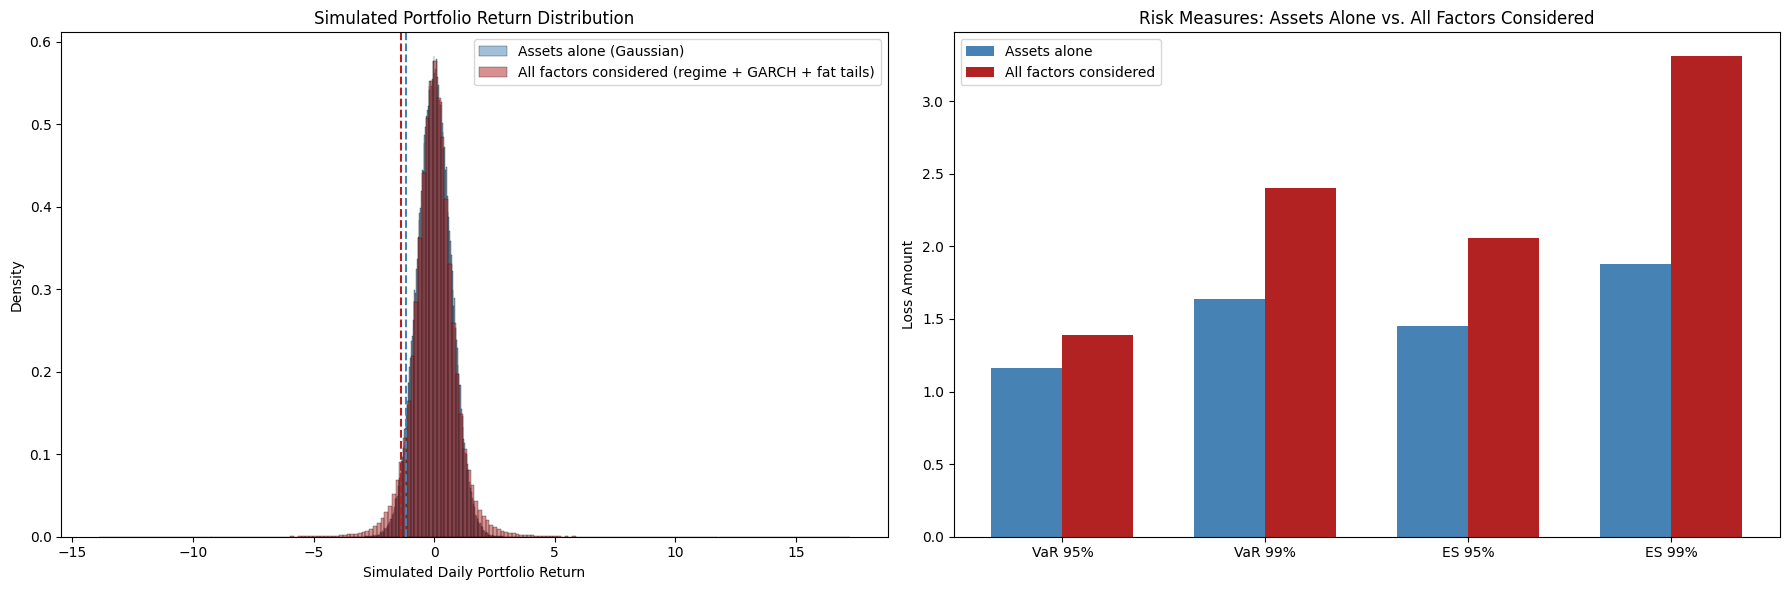

In [ ]:



plot_sample_size = min(200000, len(assets_alone_data['portfolio_returns']))
assets_alone_sample = np.random.choice(assets_alone_data['portfolio_returns'], size=plot_sample_size, replace=False)
all_factors_sample = np.random.choice(all_factors_data['portfolio_returns'], size=plot_sample_size, replace=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Overlaid distribution comparison
sns.histplot(assets_alone_sample, bins=200, stat='density', color='steelblue', alpha=0.5, label='Assets alone (Gaussian)', ax=axes[0])
sns.histplot(all_factors_sample, bins=200, stat='density', color='firebrick', alpha=0.5, label='All factors considered (regime + GARCH + fat tails)', ax=axes[0])
axes[0].axvline(-assets_alone_data['VaR'][0.95], color='steelblue', linestyle='--')
axes[0].axvline(-all_factors_data['VaR'][0.95], color='firebrick', linestyle='--')
axes[0].set_title('Simulated Portfolio Return Distribution')
axes[0].set_xlabel('Simulated Daily Portfolio Return')
axes[0].legend()

# VaR / ES comparison bars
labels = ['VaR 95%', 'VaR 99%', 'ES 95%', 'ES 99%']
assets_alone_vals = [assets_alone_data['VaR'][0.95], assets_alone_data['VaR'][0.99], assets_alone_es_95, assets_alone_es_99]
all_factors_vals = [all_factors_data['VaR'][0.95], all_factors_data['VaR'][0.99], all_factors_es_95, all_factors_es_99]

x = np.arange(len(labels))
width = 0.35
axes[1].bar(x - width/2, assets_alone_vals, width, label='Assets alone', color='steelblue')
axes[1].bar(x + width/2, all_factors_vals, width, label='All factors considered', color='firebrick')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel('Loss Amount')
axes[1].set_title('Risk Measures: Assets Alone vs. All Factors Considered')
axes[1].legend()

plt.tight_layout()
plt.show()

## v2 ADDITION: out-of-sample validation

Everything computed above is fit and "backtested" on the same data it was trained on. The function below does a simple time-ordered train/test split instead: fit minimum-variance weights and a VaR threshold on the first `train_frac` of the data, then check the exceedance rate on the held-out remainder. If the model generalizes, the observed exceedance rate on the test set should sit close to `1 - confidence_level` (e.g. close to 5% for a 95% VaR).

In [ ]:
def train_test_var_backtest(returns: pd.DataFrame, train_frac: float = 0.7, confidence_level: float = 0.95) -> dict:
    """
    Out-of-sample VaR check: fit minimum-variance weights and the VaR
    threshold on the first train_frac of the data (in time order), then
    count how many times the held-out remaining data breaches that
    threshold.
    """
    n = len(returns)
    split = int(n * train_frac)
    train, test = returns.iloc[:split], returns.iloc[split:]

    train_weights = calculate_minimum_variance_weights(train)
    train_portfolio_returns = train.values @ train_weights.values
    train_var = -np.percentile(train_portfolio_returns, (1 - confidence_level) * 100)

    test_portfolio_returns = test.values @ train_weights.values
    exceedances = int(var_backtest(test_portfolio_returns, train_var))
    n_test_obs = len(test_portfolio_returns)
    exceedance_rate = exceedances / n_test_obs if n_test_obs > 0 else float('nan')
    expected_rate = 1 - confidence_level

    return {
        'train_frac': train_frac,
        'confidence_level': confidence_level,
        'train_var': train_var,
        'n_train_obs': len(train),
        'n_test_obs': n_test_obs,
        'exceedances': exceedances,
        'exceedance_rate': exceedance_rate,
        'expected_rate': expected_rate,
    }

In [ ]:
portfolio_oos_result = train_test_var_backtest(portfolio_returns, train_frac=0.7, confidence_level=0.95)
print("Out-of-sample VaR backtest -- 20-asset portfolio:")
for k, v in portfolio_oos_result.items():
    print(f"  {k}: {v}")

Out-of-sample VaR backtest -- 20-asset portfolio:
  train_frac: 0.7
  confidence_level: 0.95
  train_var: 0.00428368233196701
  n_train_obs: 1685
  n_test_obs: 723
  exceedances: 32
  exceedance_rate: 0.04426002766251729
  expected_rate: 0.050000000000000044


##Scenario-based Monte Carlo simulation



Now we arrive at the final stage of the notebook.


This final section is where the notebook becomes a miniature portfolio risk management system, similar in philosophy (though much simpler) to what an investment bank or hedge fund might use internally.

The notebook transitions into the full-dataset Monte Carlo simulation, removes engineered variables (such as Market_Factor, Regime, and Volatility) so that only tradable assets remain, reuses the earlier portfolio optimization functions, and performs the final portfolio risk analysis.

**Bringing Everything Together**

Let's first step back.

Look at everything we've built.

Raw Market Data

  ↓

Cleaning

↓

Returns

↓

Correlation

↓

Stationarity

↓

Granger Network

↓

Regime Detection

↓

Volatility Forecasting

↓

Monte Carlo Simulation

↓

Portfolio Optimization

↓

Risk Measurement

***Notice something?***

Every chapter depends on the previous one.

Nothing was random.

Imagine You're the Chief Risk Officer

Suppose you're responsible for a

$100 billion investment fund.

Tomorrow morning your CEO asks:

"How risky is our portfolio?"

You cannot answer by saying

"Apple looks good."

You need numbers.

This notebook builds those numbers.

**Step 1 — Keep Tradable Assets and other predictive factors**

One of the fixes in this notebook adds engineered variables like:

Market_Factor
Regime
Regime_Prob
Systemic_Factor
Volatility

before running the full Monte Carlo simulation.

Why?

Because these are features that will ensure model accuracy.

You cannot buy:

❌ Regime 1

❌ Volatility

❌ Market Factor

However, they are main factors that showcase market trends and behaviours.

That's why it is germane for the computation.

You can only buy assets like:

✅ Apple

✅ Microsoft

✅ Bitcoin

✅ JPMorgan




***Step 2 — Simulating the Entire Portfolio***

Earlier,

we simulated

20 assets.

Now

the notebook simulates

the complete investment universe.

Why?

Because real investment funds rarely own only five stocks.

They often own

hundreds

or even

thousands.

Step 3 — Optimization Happens Again

The notebook reuses the optimization functions that were defined earlier instead of redefining them.

This is actually good software engineering.

Why?

Imagine writing

the same function

10 times.

If you find a bug,

you must fix

10 copies.

Instead,

write it once.

Reuse it everywhere.

Professional developers do this all the time.

Step 4 — Portfolio Risk Report

Now the notebook can answer questions like:

What is my expected return?
What is my portfolio volatility?
What is my 95% VaR?
What is my Expected Shortfall?
Which assets contribute the most risk?
How diversified am I?

These are the questions that matter to a portfolio manager.

What Is a Risk Dashboard?

Imagine you're flying an airplane.

Do pilots only look outside?

No.

They also monitor:

Altitude
Speed
Fuel
Engine temperature

Together, those instruments tell the pilot whether the plane is safe.

A portfolio manager does something similar.

Instead of airplane instruments, they monitor:

Portfolio return
Volatility
VaR
CVaR
Risk contribution
Diversification

Together, these metrics form a risk dashboard.

Step 5 — Effective Number of Assets

One metric the notebook computes is the effective number of assets.



Imagine owning

100 stocks.

Sounds diversified.

But suppose:

95% of your money is invested in

Apple.

The other 99 stocks share the remaining 5%.

Are you really diversified?

No.

The effective number of assets measures how spread out your portfolio actually is, not just how many assets appear in the list.



Step 6 — Marginal Contribution to Risk

Another function computes the marginal contribution to risk.

This answers:

If I slightly increase my investment in one asset, how much does the portfolio's overall risk increase?

***Notice something important.***

The asset with the largest weight is not always the one contributing the most risk.

For example:

Portfolio

Apple 50%
Treasury Bonds 50%

Apple may contribute far more risk than bonds because Apple is much more volatile.

Risk depends on both weight and volatility, as well as how assets interact with one another.

***Why Portfolio Managers Love This***

Imagine you're told

Apple contributes

40%

of your portfolio risk.

You now know

exactly where to investigate.

You might:

Reduce the position
Hedge it
Offset it with another asset

Without this analysis,

you're guessing.







In [ ]:
engineered_cols = ['Market_Factor', 'Regime', 'Systemic_Factor', 'Volatility']
findata_assets = findata.drop(columns=[c for c in engineered_cols if c in findata.columns])
findata_assets = findata_assets.dropna()

In [ ]:
weights_full = calculate_minimum_variance_weights(findata_assets)
weights_full

,0
AAPL,-1.803260e-03
AVGO,-9.310057e-05
BRK-B,-5.640819e-05
GOOG,1.315756e-03
META,-2.965095e-04
MSFT,-8.270989e-04
NVDA,3.176285e-04
BAC,8.049931e-04
GS,9.156615e-04
JPM,-3.257534e-04


In [ ]:
simulated_portfolio_data_full = calculate_portfolio_var(
    generate_correlated_returns(3000000, findata_assets),
    weights_full,
    confidence_levels=[0.95, 0.99]
)
simulated_portfolio_data_full

{'portfolio_returns': array([-0.56881048,  0.20478338, -0.47511219, ..., -0.32022165,
         0.09823504, -0.37732876]),
 'portfolio_mean': np.float64(-0.00047891934622853484),
 'portfolio_std': np.float64(0.6589321885124267),
 'VaR': {0.95: np.float64(1.0841464206668048),
  0.99: np.float64(1.5335924125386184)}}

In [ ]:
print("Standard Deviation of Asset Returns:")
print(findata_assets.std())

Standard Deviation of Asset Returns:
AAPL             0.016450
AVGO             0.023101
BRK-B            0.010861
GOOG             0.016954
META             0.022886
MSFT             0.015948
NVDA             0.027208
BAC              0.017512
GS               0.017299
JPM              0.016077
MS               0.018095
AMZN             0.018722
TSLA             0.033996
WMT              0.012177
BTC-USD          0.031292
ETH-USD          0.041930
XRP-USD          0.053591
BABA             0.025578
HDB              0.017082
PBR              0.025390
TSM              0.020606
ZENB.L           0.005960
EWZ              0.018607
INDA             0.011739
VWO              0.010770
^OVX             0.065695
^VIX             0.069912
^VXN             0.053223
DCOILWTICO       0.073169
DCOILBRENTEU     0.029764
DEXUSEU          0.003848
DEXUSUK          0.004568
DEXJPUS          0.004999
VIXCLS           0.069637
DTWEXBGS         0.002726
DGS10            0.027238
DGS30            0.019304
B

FIX #6: the original call here was calculate_expected_shortfall(findata, confidence_level=0.95), it passed the whole multi-column findata DataFrame directly (mixing GDP, FX rates, stock returns, etc. together) instead of the simulated 1-D portfolio-return series the function is meant to take, the way the portfolio section correctly does it above. Fixed to pass simulated_portfolio_data_full['portfolio_returns'] instead.

In [ ]:
calculate_expected_shortfall(simulated_portfolio_data_full['portfolio_returns'], confidence_level=0.95)

np.float64(1.3590348083344297)

FIX #5: same var_backtest misuse as FIX #4, repeated here for the full dataset, corrected the same way.

In [ ]:
_historical_portfolio_returns_full = findata_assets.values @ weights_full.values
_historical_var_95_full = -np.percentile(_historical_portfolio_returns_full, 5)

var_backtest(_historical_portfolio_returns_full, _historical_var_95_full)

np.int64(121)

In [ ]:
effective_number_of_assets(weights_full)

np.float64(1.9620417739995777)

In [ ]:
marginal_contribution_to_risk(findata_assets, weights_full)

array([0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003, 0.00038003, 0.00038003,
       0.00038003, 0.00038003, 0.00038003])

FIX #7: the original final chart cell read portfolio_simulated_returns = simulated_portfolio_data['findata'], 'findata' is not a key that calculate_portfolio_var returns (it returns 'portfolio_returns', 'portfolio_mean', 'portfolio_std', 'VaR'), so this would raise a KeyError. Fixed below, and updated to reference the full-dataset simulation (simulated_portfolio_data_full) rather than the portfolio-only one.

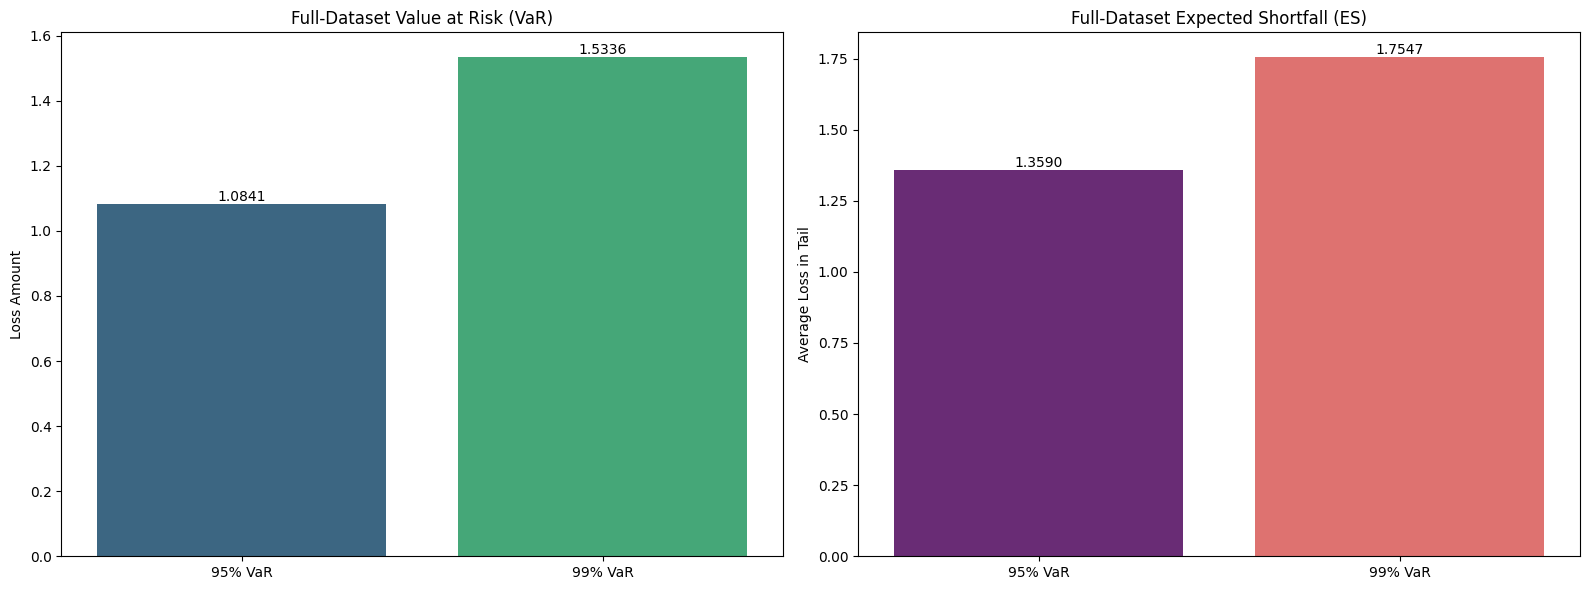

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

portfolio_simulated_returns_full = simulated_portfolio_data_full['portfolio_returns']
var_95 = simulated_portfolio_data_full['VaR'][0.95]
var_99 = simulated_portfolio_data_full['VaR'][0.99]

# Calculate Expected Shortfall for the full dataset
es_95 = calculate_expected_shortfall(portfolio_simulated_returns_full, confidence_level=0.95)
es_99 = calculate_expected_shortfall(portfolio_simulated_returns_full, confidence_level=0.99)

# Create the subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# VaR Plot
confidence_labels = ['95% VaR', '99% VaR']
var_values = [var_95, var_99]
sns.barplot(x=confidence_labels, y=var_values, ax=axes[0], palette='viridis', hue=confidence_labels, legend=False)
axes[0].set_title('Full-Dataset Value at Risk (VaR)')
axes[0].set_ylabel('Loss Amount')
for index, value in enumerate(var_values):
    axes[0].text(index, value, f'{value:.4f}', ha='center', va='bottom')

# Expected Shortfall Plot
es_values = [es_95, es_99]
sns.barplot(x=confidence_labels, y=es_values, ax=axes[1], palette='magma', hue=confidence_labels, legend=False)
axes[1].set_title('Full-Dataset Expected Shortfall (ES)')
axes[1].set_ylabel('Average Loss in Tail')
for index, value in enumerate(es_values):
    axes[1].text(index, value, f'{value:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
findata_assets_oos_result = train_test_var_backtest(findata_assets, train_frac=0.7, confidence_level=0.95)
print("Out-of-sample VaR backtest -- full dataset:")
for k, v in findata_assets_oos_result.items():
    print(f"  {k}: {v}")

Out-of-sample VaR backtest -- full dataset:
  train_frac: 0.7
  confidence_level: 0.95
  train_var: 0.00038914414781990526
  n_train_obs: 1685
  n_test_obs: 723
  exceedances: 23
  exceedance_rate: 0.0318118948824343
  expected_rate: 0.050000000000000044


# That is all for this project ensure you try it out yourself and improve as time passes

>Thank you and do subscribe to my Youtube channel; Audit2alpha

>And check our services to see how we can help your business make the right decision at Augmatics.net